# Desafio Técnico - Gato Mestre (Ciência de Dados)
## Etapa 1: Análise exploratória (IDE-CURSOR)

Está notebook é responsável por:
1. Carragar os arquivos /data
2. Analisar de forma detalhada os dados e suas relações

In [1]:
from pathlib import Path
import json
import time
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import requests
import itables
from itables import init_notebook_mode, show
import requests

# Adiciona o diretório raiz ao sys.path para importar módulos de src
PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

# Renderização inline do matplotlib
%matplotlib inline

# Configurações estéticas e de formatação
warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:.2f}")

# Ativa tabelas interativas (com busca em tempo real, ordenação por coluna e paginação)
init_notebook_mode(all_interactive=True)
itables.options.maxBytes = 0
itables.options.classes = ["display", "nowrap"]
itables.options.lengthMenu = [10, 25, 50, 100]

print(f"Pandas version: {pd.__version__}")
print(f"Numpy version: {np.__version__}")
print(f"Itables version: {itables.__version__}")

Pandas version: 3.0.5
Numpy version: 2.5.2
Itables version: 2.9.1


In [2]:
# carregar o arquivo df.parquet
df = pd.read_parquet("../data/processed/base_limpa_gm.parquet")
df.head(1)

atleta_id      apelido   ano  rodada_id  clube_id  posicao_id status_pre  \
0      10001  Elias Ramos  2022         35       115           6   Provável   

  status_inicial  preco_num  variacao_num  media_num  jogos_num  pontos_num  \
0        reserva       5.35         -0.65       1.87          1        1.87   

   minutos_jogados  entrou_em_campo  home_dummy  opponent  match_id    G    A  \
0            90.00             True           1       121    900166 0.00 0.00   

    SG   FF   FT   FD   DP   DE   DS   FS   PS   GS   GC   CA   CV   FC    I  \
0 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00   

    PP   PC  rodada_cbf_original  
0 0.00 0.00                   35

#### Análise da temporada

1 nova feature que segmenta o comportamento da temporada em 3 partes 
* "início temporada (R1-R5)", 
* "meio temporada R6-R30", 
* "final temporada R31-R38"<br>

2 identificado e tratado o Target Concept Drift <br>

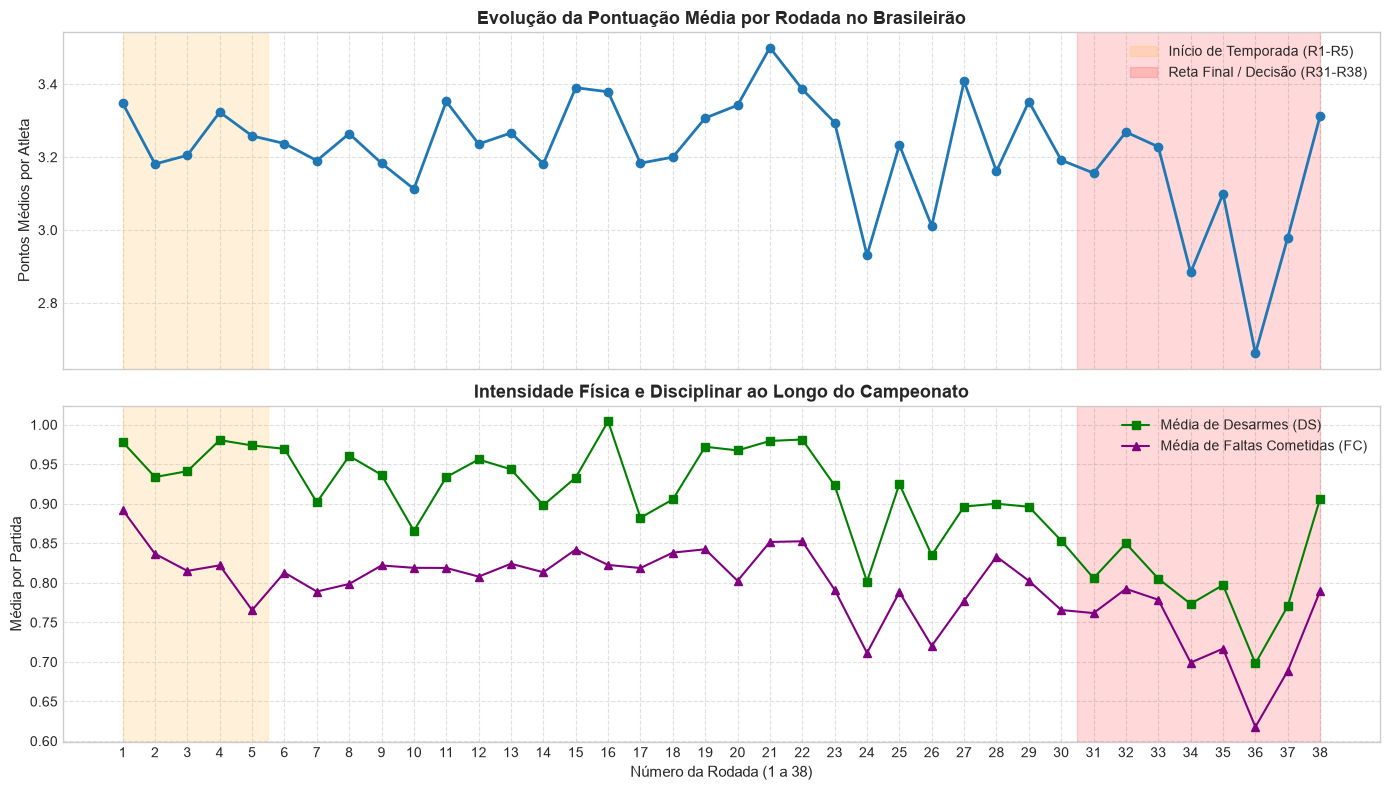

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1.1 Média de Pontos por Rodada ao longo das temporadas
df_rodada_stats = (
    df[df['entrou_em_campo'] == True]
    .groupby('rodada_id')
    .agg(
        pontos_medios=('pontos_num', 'mean'),
        desarmes_medios=('DS', 'mean'),
        faltas_medias=('FC', 'mean'),
        cartoes_medios=('CA', 'mean'),
    )
    .reset_index()
)

# 1.2 Gráfico de Linhas: Dinâmica das 38 Rodadas
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Pontuação Média por Rodada
ax1.plot(
    df_rodada_stats['rodada_id'],
    df_rodada_stats['pontos_medios'],
    marker='o',
    color='#1f77b4',
    linewidth=2,
)
ax1.axvspan(
    1, 5.5, color='orange', alpha=0.15, label='Início de Temporada (R1-R5)'
)
ax1.axvspan(
    30.5, 38, color='red', alpha=0.15, label='Reta Final / Decisão (R31-R38)'
)
ax1.set_ylabel('Pontos Médios por Atleta', fontsize=11)
ax1.set_title(
    'Evolução da Pontuação Média por Rodada no Brasileirão',
    fontsize=13,
    fontweight='bold',
)
ax1.legend(loc='upper right')
ax1.grid(True, linestyle='--', alpha=0.6)

# Scouts Disciplinares/Físicos por Rodada (Faltas e Desarmes)
ax2.plot(
    df_rodada_stats['rodada_id'],
    df_rodada_stats['desarmes_medios'],
    marker='s',
    color='green',
    label='Média de Desarmes (DS)',
)
ax2.plot(
    df_rodada_stats['rodada_id'],
    df_rodada_stats['faltas_medias'],
    marker='^',
    color='purple',
    label='Média de Faltas Cometidas (FC)',
)
ax2.axvspan(1, 5.5, color='orange', alpha=0.15)
ax2.axvspan(30.5, 38, color='red', alpha=0.15)
ax2.set_xlabel('Número da Rodada (1 a 38)', fontsize=11)
ax2.set_ylabel('Média por Partida', fontsize=11)
ax2.set_title(
    'Intensidade Física e Disciplinar ao Longo do Campeonato',
    fontsize=13,
    fontweight='bold',
)
ax2.set_xticks(range(1, 39))
ax2.legend(loc='upper right')
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

=== RESULTADO DO TESTE ESTATÍSTICO (ANOVA) ===
Estatística F: 7.34
P-valor:       6.4842e-05
Conclusão:     A diferença de pontuação entre as fases é ESTATISTICAMENTE SIGNIFICATIVA.
               Validado! A feature 'regime_temporada' tem poder preditivo.


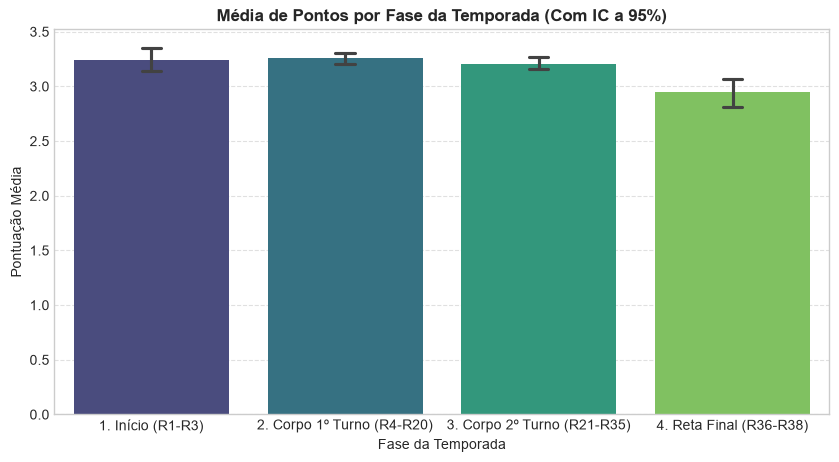

In [4]:
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Criação da feature com a sua lógica de 4 Fases
def classificar_fase(rodada):
    if rodada <= 3:
        return '1. Início (R1-R3)'
    elif rodada <= 20:
        return '2. Corpo 1º Turno (R4-R20)'
    elif rodada <= 35:
        return '3. Corpo 2º Turno (R21-R35)'
    else:
        return '4. Reta Final (R36-R38)'

df['regime_temporada'] = df['rodada_id'].apply(classificar_fase)

# 2. Preparar os dados para o Teste Estatístico (Filtrando quem jogou)
df_validos = df[df['entrou_em_campo'] == True].dropna(subset=['pontos_num'])

# Separar os grupos em listas de pontuações
grupos = [grupo['pontos_num'].values for nome, grupo in df_validos.groupby('regime_temporada')]

# 3. Executar a ANOVA
f_stat, p_valor = stats.f_oneway(*grupos)

print(f"=== RESULTADO DO TESTE ESTATÍSTICO (ANOVA) ===")
print(f"Estatística F: {f_stat:.2f}")
print(f"P-valor:       {p_valor:.4e}")

if p_valor < 0.05:
    print("Conclusão:     A diferença de pontuação entre as fases é ESTATISTICAMENTE SIGNIFICATIVA.")
    print("               Validado! A feature 'regime_temporada' tem poder preditivo.")
else:
    print("Conclusão:     Não há diferença significativa. A variação pode ser mero acaso.")

# 4. Comprovação Visual Limpa (Barplot com Intervalo de Confiança)
ordem_fases = [
    '1. Início (R1-R3)',
    '2. Corpo 1º Turno (R4-R20)',
    '3. Corpo 2º Turno (R21-R35)',
    '4. Reta Final (R36-R38)',
]

plt.figure(figsize=(10, 5))
sns.barplot(
    x='regime_temporada',
    y='pontos_num',
    data=df_validos,
    order=ordem_fases,  # Força a sequência temporal exata
    palette='viridis',
    capsize=0.1,
)
plt.title(
    'Média de Pontos por Fase da Temporada (Com IC a 95%)', fontweight='bold'
)
plt.xlabel('Fase da Temporada')
plt.ylabel('Pontuação Média')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

Boxplot de Pontos por Posição:


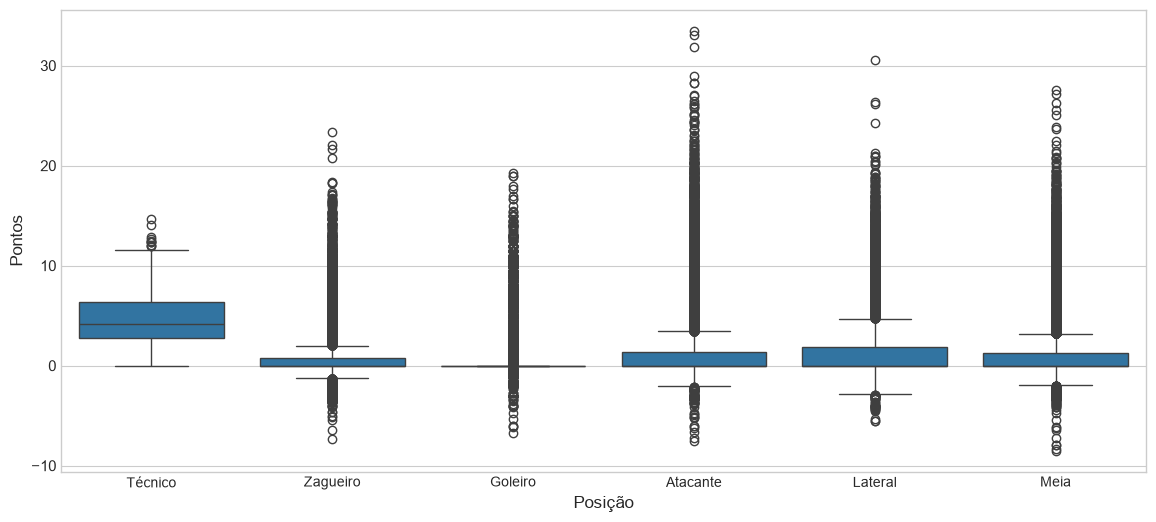

Boxplot de Pontos por Regime Temporada e Posição (ordenado):


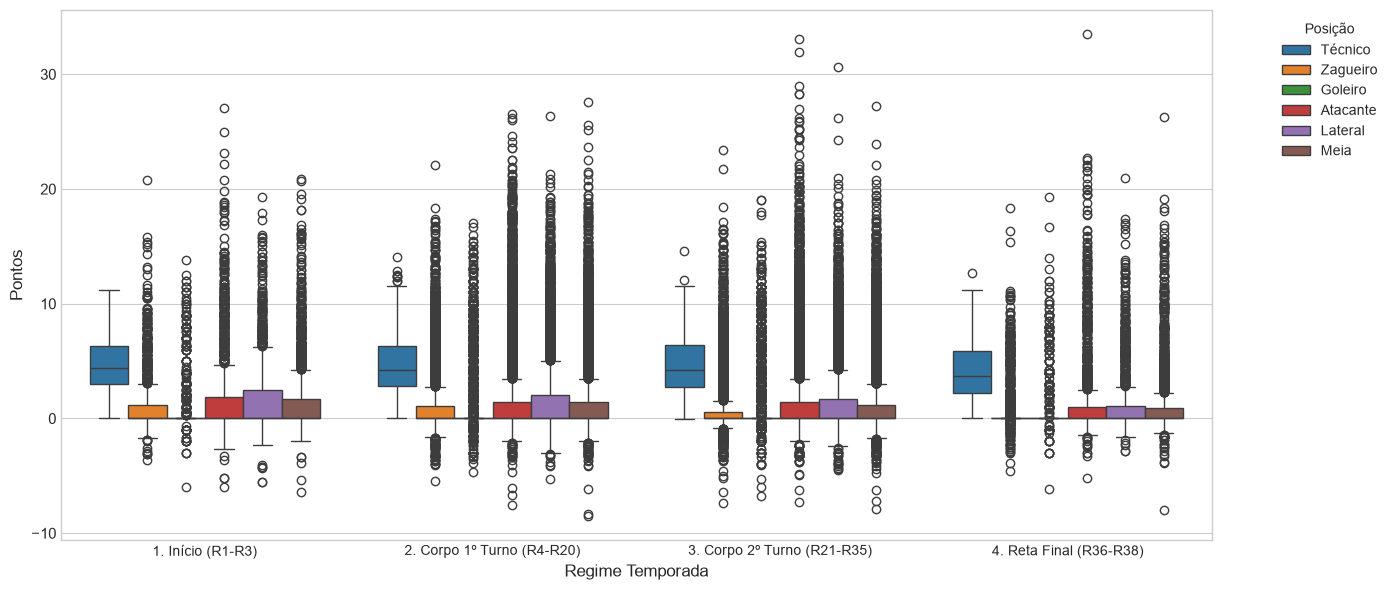

Variância de Pontos por Posição e Ano:
ano           2022  2023  2024  2025
posicao_nome                        
Atacante      9.71 11.48 10.21 12.40
Lateral       8.51  9.65  9.27 12.04
Goleiro       5.51  6.53  5.64  7.87
Técnico       4.95  6.68  6.99  7.69
Zagueiro      6.11  6.11  5.90  7.23
Meia          6.42  6.46  7.06  6.94

⚠️ Parece que a temporada de 2025 tem um comportamento diferente das outras



In [5]:
# nome das posições
mapa_posicoes = {
    1: 'Goleiro',
    2: 'Lateral',
    3: 'Zagueiro',
    4: 'Meia',
    5: 'Atacante',
    6: 'Técnico'
}

# Criando a feature posicao_nome no dataframe atual
df['posicao_nome'] = df['posicao_id'].map(mapa_posicoes)

# variacao de pontos_num por posicao_nome no boxplot
print("Boxplot de Pontos por Posição:")
fig, ax = plt.subplots(figsize=(14, 6))
sns.boxplot(x="posicao_nome", y="pontos_num", data=df, ax=ax)
ax.set_ylabel("Pontos", fontsize=12)
ax.set_xlabel("Posição", fontsize=12)
ax.tick_params(axis='y', labelsize=11)
plt.show()

# fazer uma análise de regime_temporada por pontos_num para cada posicao_nome, ordenando regime_temporada
print("Boxplot de Pontos por Regime Temporada e Posição (ordenado):")

# Definir a ordem desejada de regime_temporada, se você souber (exemplo abaixo). 
# Ajuste conforme suas categorias reais.
regime_ordem = sorted(df['regime_temporada'].dropna().unique())
# Ou especifique manualmente, ex: ['Regular', 'Playoff', 'Final']

fig, ax = plt.subplots(figsize=(14, 6))
sns.boxplot(
    x="regime_temporada", 
    y="pontos_num", 
    data=df, 
    hue="posicao_nome", 
    ax=ax, 
    order=regime_ordem
)
ax.set_ylabel("Pontos", fontsize=12)
ax.set_xlabel("Regime Temporada", fontsize=12)
ax.tick_params(axis='y', labelsize=11)
ax.legend(title="Posição", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


# tabela variancia por posicao_nome em cada ano (cada coluna com uma ano, cada linha com uma posicao_nome)
print("Variância de Pontos por Posição e Ano:")
print(df.groupby(["posicao_nome", "ano"])["pontos_num"].var().unstack().sort_values(by=2025, ascending=False))

print("""
⚠️ Parece que a temporada de 2025 tem um comportamento diferente das outras
""")

In [6]:
def auditar_regras_pontuacao_scouts(
    df: pd.DataFrame, ano_base: int = 2024, ano_comparacao: int = 2025
) -> pd.DataFrame:
  """Executa a auditoria reversa e determinística das regras de pontuação de scouts por temporada.

  A função isola 'casos puros' (partidas onde o atleta teve uma única ação
  registrada
  e zero em todas as demais) para extrair o valor nominal exato (moda estatística)
  atribuído a cada scout, eliminando ruídos amostrais ou médias ponderadas.

  Tratamentos específicos:
  1. Scouts Gerais / Linha: Isola ocorrências onde Scout_i == 1 e todos os
  outros 17 scouts são 0.
  2. Defesa de Goleiro (DE): Como goleiros quase nunca terminam sem SG ou GS,
  avalia casos com SG == 1, DE == 1 e sem outras infrações, subtraindo os 5.0
  pts do SG.

  Parâmetros:
  -----------
  df : pd.DataFrame
      Dataframe contendo os scouts brutos, a coluna de pontuação ('pontos_num') e
      a temporada ('ano').
  ano_base : int, default 2024
      Temporada de referência anterior para comparação.
  ano_comparacao : int, default 2025
      Temporada mais recente para detecção de alterações na regra.

  Retorno:
  --------
  pd.DataFrame
      Tabela consolidada com o valor nominal de cada scout por ano, delta
      absoluto,
      variação percentual e flag indicativa de mudança de regra.
  """
  scouts_linha = [
      'G',
      'A',
      'SG',
      'DS',
      'FS',
      'FD',
      'FF',
      'FT',
      'DP',
      'GS',
      'FC',
      'CA',
      'CV',
      'I',
      'PP',
      'PC',
      'GC',
  ]
  todos_scouts = scouts_linha + ['DE']

  registros_regras = []

  # --- 1. AUDITORIA DOS SCOUTS DE LINHA E GERAIS ---
  for scout in scouts_linha:
    outros = [s for s in todos_scouts if s != scout]
    filtro_puro = (df[scout] == 1) & (df[outros].abs().sum(axis=1) == 0)
    df_puro = df[filtro_puro]

    if not df_puro.empty:
      for ano, dados_ano in df_puro.groupby('ano'):
        if len(dados_ano) > 0:
          moda_val = dados_ano['pontos_num'].mode()[0]
          registros_regras.append(
              {'scout': scout, 'ano': ano, 'valor_nominal': moda_val}
          )

  # --- 2. AUDITORIA ESPECÍFICA DE GOLEIRO (DE) ---
  scouts_zerar_gk = [s for s in todos_scouts if s not in ['SG', 'DE']]
  filtro_gk = (
      (df['posicao_nome'].str.contains('Goleiro', na=False))
      & (df['SG'] == 1)
      & (df['DE'] == 1)
      & (df[scouts_zerar_gk].abs().sum(axis=1) == 0)
  )
  df_gk = df[filtro_gk]

  if not df_gk.empty:
    for ano, dados_ano in df_gk.groupby('ano'):
      if len(dados_ano) > 0:
        val_de = round(dados_ano['pontos_num'].mode()[0] - 5.0, 2)
        registros_regras.append(
            {'scout': 'DE', 'ano': ano, 'valor_nominal': val_de}
        )

  # --- 3. CONSOLIDAÇÃO E GERAÇÃO DO DIAGNÓSTICO ---
  df_regras = pd.DataFrame(registros_regras)
  tabela_consolidada = df_regras.pivot(
      index='scout', columns='ano', values='valor_nominal'
  )

  if (
      ano_base in tabela_consolidada.columns
      and ano_comparacao in tabela_consolidada.columns
  ):
    tabela_consolidada['delta_pts'] = (
        tabela_consolidada[ano_comparacao] - tabela_consolidada[ano_base]
    ).round(2)
    tabela_consolidada['variacao_pct'] = (
        (tabela_consolidada['delta_pts'] / tabela_consolidada[ano_base].abs())
        * 100
    ).round(1)
    tabela_consolidada['mudou_regra'] = (
        tabela_consolidada[ano_base] != tabela_consolidada[ano_comparacao]
    )

  # Formatação e Exibição Executiva
  print('=' * 75)
  print(
      f'RELATÓRIO DE AUDITORIA DE REGRAS DE SCOUT ({ano_base} vs.'
      f' {ano_comparacao})'
  )
  print('=' * 75)
  print(tabela_consolidada.to_string())

  alterados = tabela_consolidada[
      tabela_consolidada.get('mudou_regra', False) == True
  ]
  print('\n' + '-' * 75)
  print('DIAGNÓSTICO EXECUTIVO:')
  if not alterados.empty:
    for scout, row in alterados.iterrows():
      print(
          f" • Scout [{scout}]: Reajustado de {row[ano_base]:+.2f} para"
          f' {row[ano_comparacao]:+.2f} pts ({row["variacao_pct"]:+.1f}%).'
      )
    print(
        '\nConclusão: O aumento nas médias de pontuação em 2025 decorre exclusivamente'
    )
    print(
        'da valorização dos scouts defensivos acima, sem impacto no rendimento físico/tático.'
    )
  else:
    print(' • Nenhuma alteração de regra detectada entre as temporadas.')
  print('-' * 75)

  return tabela_consolidada


# Execução direta na célula:
tabela_regras = auditar_regras_pontuacao_scouts(df)

RELATÓRIO DE AUDITORIA DE REGRAS DE SCOUT (2024 vs. 2025)
ano    2022  2023  2024  2025  delta_pts  variacao_pct  mudou_regra
scout                                                              
A      4.70  5.00  5.00  5.00       0.00          0.00        False
CA    -1.00 -1.00 -1.00 -1.00       0.00          0.00        False
CV    -3.00 -3.00 -3.00 -3.00       0.00          0.00        False
DE     1.00  1.00  1.00  1.30       0.30         30.00         True
DS     1.10  1.20  1.20  1.50       0.30         25.00         True
FC    -0.40 -0.30 -0.30 -0.30       0.00          0.00        False
FD     1.10  1.20  1.20  1.20       0.00          0.00        False
FF     0.70  0.80  0.80  0.80       0.00          0.00        False
FS     0.30  0.50  0.50  0.50       0.00          0.00        False
FT     2.40  3.00  3.00  3.00       0.00          0.00        False
G      8.00  8.00  8.00  8.00       0.00          0.00        False
GC    -3.10 -3.00 -3.00   NaN        NaN           NaN    

##### O que fazer agora?

1. entender como esse dado está na API e ver a possibilidade de subscrever
2. replicar o novo modelo de pontuação para os anos de 2022, 2023 e 2024 de forma retroativa

In [7]:
import json
import pandas as pd

# ── 1. Carregar arquivos ──────────────────────────────────────────────
with open("../data/raw/api_atletas.json") as f:
    atletas = pd.DataFrame(json.load(f))

with open("../data/raw/api_equipes.json") as f:
    equipes = pd.DataFrame(json.load(f))

with open("../data/raw/api_jogos.json") as f:
    jogos = pd.DataFrame(json.load(f))

with open("../data/raw/api_confrontos.json") as f:
    confrontos_raw = json.load(f)

with open("../data/raw/api_jogos_detalhes.json") as f:
    detalhes_raw = json.load(f)

# ── 2. Normalizar confrontos — usa 'edicao' para consistência ─────────
confrontos_list = []
for chave, registros in confrontos_raw.items():
    edicao, rodada = chave.split("/")
    for reg in registros:
        reg["edicao"] = int(edicao)
        reg["rodada"] = int(rodada)
        confrontos_list.append(reg)

confrontos = pd.DataFrame(confrontos_list)

# ── 3. Normalizar detalhes dos jogos (escalações) ─────────────────────
escalacao_list = []
for entrada in detalhes_raw:
    jogo_info = entrada["resultados"]["jogo"]
    escalacao = entrada["referencias"].get("escalacao", {})

    for equipe_id_str, listas in escalacao.items():
        equipe_id = int(equipe_id_str)

        for atleta in listas.get("titulares", []):
            escalacao_list.append({
                **jogo_info,
                "equipe_id": equipe_id,
                "atleta_id": atleta["atleta_id"],
                "titular": True,
                "substituido_em": atleta.get("substituido", {}).get("momento"),
                "entrou_em": None,
            })

        for atleta in listas.get("reservas", []):
            escalacao_list.append({
                **jogo_info,  # <-- Corrigido aqui
                "equipe_id": equipe_id,
                "atleta_id": atleta["atleta_id"],
                "titular": False,
                "substituido_em": None,
                "entrou_em": atleta.get("entrou", {}).get("momento"),
            })

escalacoes = pd.DataFrame(escalacao_list)

# ── 4. Enriquecer com atletas e nomes de equipes ──────────────────────
df_api = escalacoes.merge(atletas, on="atleta_id", how="left")

df_api = df_api.merge(
    equipes.rename(columns={"nome": "equipe_nome", "sigla": "equipe_sigla"}),
    on="equipe_id",
    how="left"
)

df_api = df_api.merge(
    equipes.rename(columns={
        "equipe_id": "equipe_mandante_id",
        "nome": "mandante_nome",
        "sigla": "mandante_sigla",
    }),
    on="equipe_mandante_id",
    how="left"
)

df_api = df_api.merge(
    equipes.rename(columns={
        "equipe_id": "equipe_visitante_id",
        "nome": "visitante_nome",
        "sigla": "visitante_sigla",
    }),
    on="equipe_visitante_id",
    how="left"
)

# ── 5. Flag se o atleta joga em casa ou fora ──────────────────────────
df_api["home"] = df_api["equipe_id"] == df_api["equipe_mandante_id"]

# ── 6. Adicionar médias de confronto ──────────────────────────────────
df_api = df_api.merge(
    confrontos.rename(columns={
        "equipe_media_pontos_conquistados": "media_pts_conquistados",
        "adversario_media_pontos_cedidos": "adversario_media_pts_cedidos",
    }),
    on=["equipe_id", "edicao", "rodada"],
    how="left"
)

# ── Resultado ──────────────────────────────────────────────────────────
print(f"Shape final: {df_api.shape}")
print(df_api.columns.tolist())

print(" ⚠️ : não existe esse dado na API")
df_api.head(3)


Shape final: (109314, 23)
['jogo_id', 'edicao', 'rodada', 'equipe_mandante_id', 'equipe_visitante_id', 'equipe_id', 'atleta_id', 'titular', 'substituido_em', 'entrou_em', 'apelido', 'posicao_id', 'clube_id', 'equipe_nome', 'equipe_sigla', 'mandante_nome', 'mandante_sigla', 'visitante_nome', 'visitante_sigla', 'home', 'adversario_id', 'media_pts_conquistados', 'adversario_media_pts_cedidos']
 ⚠️ : não existe esse dado na API


jogo_id  edicao  rodada  equipe_mandante_id  equipe_visitante_id  \
0   900001    2022       1                 111                  114   
1   900001    2022       1                 111                  114   
2   900001    2022       1                 111                  114   

   equipe_id  atleta_id  titular substituido_em entrou_em            apelido  \
0        111      10418     True          80min       NaN  Ubirajara Escobar   
1        111      10167     True          58min       NaN                NaN   
2        111      10835     True            NaN       NaN      Joaquim Gomes   

   posicao_id  clube_id equipe_nome equipe_sigla mandante_nome mandante_sigla  \
0        5.00    105.00   Clube 111         C111     Clube 111           C111   
1         NaN       NaN   Clube 111         C111     Clube 111           C111   
2        2.00    105.00   Clube 111         C111     Clube 111           C111   

  visitante_nome visitante_sigla  home  adversario_id  media_pts_conquistados  \
0      Clube 114            C114  True            NaN                     NaN   
1      Clube 114            C114  True            NaN                     NaN   
2      Clube 114            C114  True            NaN                     NaN   

   adversario_media_pts_cedidos  
0                           NaN  
1                           NaN  
2                           NaN

In [8]:
# 1. Regras oficiais de 2025
regras_2025 = {
    'G': 8.0,
    'A': 5.0,
    'SG': 5.0,
    'DS': 1.5,
    'DE': 1.3,
    'FS': 0.5,
    'FD': 1.2,
    'FF': 0.8,
    'FT': 3.0,
    'DP': 7.0,
    'GS': -1.0,
    'FC': -0.3,
    'CA': -1.0,
    'CV': -3.0,
    'I': -0.1,
    'PP': -4.0,
    'PC': -1.0,
    'GC': -3.0,
}

# 2. Recálculo do target para jogadores de linha e goleiros
df['pontos_target_2025'] = sum(
    df[scout] * peso for scout, peso in regras_2025.items()
)

# 3. Média dos jogadores escalados do clube para atribuir aos técnicos (sem gerar NaN)
mask_jogadores = (df['posicao_id'] != 6) & (
    df['entrou_em_campo'] == True
)
medias_times = (
    df[mask_jogadores]
    .groupby(['ano', 'rodada_id', 'clube_id'])['pontos_target_2025']
    .mean()
)

mask_tecnicos = df['posicao_id'] == 6
chaves_tecnicos = df.loc[
    mask_tecnicos, ['ano', 'rodada_id', 'clube_id']
].apply(tuple, axis=1)
df.loc[mask_tecnicos, 'pontos_target_2025'] = chaves_tecnicos.map(
    medias_times
)

# 4. Tabelas de Variância: Original vs. Homogeneizada
print('=== 1. Variância Original por Posição e Ano (pontos_num) ===')
print(
    df.groupby(['posicao_nome', 'ano'])['pontos_num']
    .var()
    .unstack()
    .sort_values(by=2025, ascending=False)
    .round(2)
)

print(
    '\n=== 2. Variância Homogeneizada por Posição e Ano (pontos_target_2025)'
    ' ==='
)
print(
    df.groupby(['posicao_nome', 'ano'])['pontos_target_2025']
    .var()
    .unstack()
    .sort_values(by=2025, ascending=False)
    .round(2)
)


=== 1. Variância Original por Posição e Ano (pontos_num) ===
ano           2022  2023  2024  2025
posicao_nome                        
Atacante      9.71 11.48 10.21 12.40
Lateral       8.51  9.65  9.27 12.04
Goleiro       5.51  6.53  5.64  7.87
Técnico       4.95  6.68  6.99  7.69
Zagueiro      6.11  6.11  5.90  7.23
Meia          6.42  6.46  7.06  6.94

=== 2. Variância Homogeneizada por Posição e Ano (pontos_target_2025) ===
ano           2022  2023  2024  2025
posicao_nome                        
Atacante     11.21 12.09 10.81 12.26
Lateral      11.91 11.21 10.65 11.93
Goleiro       7.64  8.90  7.84  7.96
Zagueiro      7.76  7.01  6.75  7.25
Meia          8.65  7.52  8.17  6.94
Técnico       2.54  2.23  2.27  2.39


## 2.feature engineer

### 2.1 Engenharia de Features: Força Coletiva e Contexto do Confronto (Métricas da API)

#### Racional Teórico e de Domínio

O desempenho individual de um atleta no Cartola FC é fortemente condicionado pelo contexto coletivo da partida. Modelos preditivos que avaliam apenas o histórico individual ignoram dois fatores determinantes:

1. **Momento Ofensivo do Clube:** Equipes com maior volume de criação recente geram mais oportunidades de scouts positivos (`G`, `A`, `FD`, `FF`, `FS`) para seus jogadores.
2. **Permissividade Defensiva do Oponente:** Equipes que cedem muitos pontos gerais aos adversários costumam ser alvos ideais para escalação, independentemente do histórico individual recente.

---

#### Variáveis Construídas e Fórmulas

* **`clube_media_pts_feitos_l5` (Potencial Ofensivo da Equipe):** Média móvel dos pontos totais conquistados pelos atletas do clube nas últimas 5 partidas.

$$\text{PtsEquipe}_{t, c} = \sum_{i \in c} \text{PontosTarget}_i$$


$$\text{clube\_media\_pts\_feitos\_l5} = \frac{1}{5} \sum_{i=1}^{5} \text{PtsEquipe}_{t-i}$$


* **`adv_media_pts_cedidos_l5` (Vulnerabilidade do Oponente):** Mapeamento da mesma média móvel de pontos, mas direcionada ao time adversário da rodada atual (`opponent`).

$$\text{adv\_media\_pts\_cedidos\_l5} = \text{clube\_media\_pts\_feitos\_l5} \text{ (do time rival)}$$


* **Fallback Inicial (Imputação de Rodadas Iniciais):** Tratamento para as primeiras rodadas que não possuem o histórico completo de 5 jogos, utilizando a média global multiplicada por 11 atletas:

$$\text{Fallback} = \mu_{\text{temporada}} \times 11$$



---

#### Cuidados Metodológicos (Prevenção de Data Leakage)

* **Aplicação de `.shift(1)`:** As métricas móveis consideram estritamente o passado ($t-1$ para trás), evitando que dados da rodada atual vazem para o modelo.
* **Janela Dinâmica:** Utiliza `.rolling(5, min_periods=1)` para acomodar o histórico progressivo das primeiras rodadas com segurança.

Shape atual do DataFrame: (115613, 43)
Novas features criadas: ['clube_media_pts_feitos_l5', 'adv_media_pts_cedidos_l5']

--- Exemplo Prático: Atleta em uma Rodada ---
 ano  rodada_id  atleta_id  clube_id  opponent  clube_media_pts_feitos_l5  adv_media_pts_cedidos_l5  pontos_target_2025
2022         35      10001       115       121                      40.71                     52.69                2.11

--- Matriz de Correlação com a Pontuação Final ---
                           pontos_target_2025  clube_media_pts_feitos_l5  adv_media_pts_cedidos_l5
pontos_target_2025                       1.00                       0.03                     -0.00
clube_media_pts_feitos_l5                0.03                       1.00                      0.11
adv_media_pts_cedidos_l5                -0.00                       0.11                      1.00


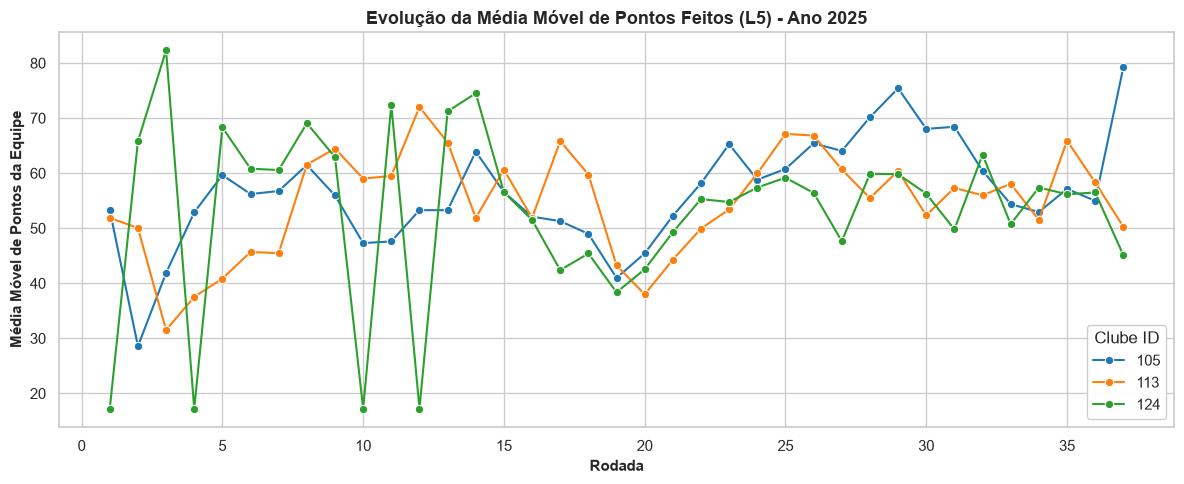

In [9]:
# ── Bloco 2: Força do Clube e do Oponente (API) ───────────────────────────
# 1. Remove colunas antigas se já existirem no df para evitar conflito de merge
colunas_para_remover = ['clube_media_pts_feitos_l5', 'adv_media_pts_cedidos_l5']
df = df.drop(columns=[c for c in colunas_para_remover if c in df.columns], errors='ignore')

# 2. Total de pontos produzidos por equipe em cada jogo/rodada (apenas atletas que jogaram)
pontos_por_clube_jogo = (
    df[df['entrou_em_campo']]
    .groupby(['ano', 'rodada_id', 'clube_id'])['pontos_target_2025']
    .sum()
    .reset_index()
    .rename(columns={'pontos_target_2025': 'pts_conquistados_equipe'})
)

# 3. Ordena temporalmente para calcular rolling lags sem data leakage (shift 1)
pontos_por_clube_jogo = pontos_por_clube_jogo.sort_values(['ano', 'clube_id', 'rodada_id'])

# Média móvel dos últimos 5 jogos da equipe (pts feitos)
pontos_por_clube_jogo['clube_media_pts_feitos_l5'] = (
    pontos_por_clube_jogo.groupby(['ano', 'clube_id'])['pts_conquistados_equipe']
    .transform(lambda s: s.shift(1).rolling(5, min_periods=1).mean())
)

# 4. Prepara dataframes separados para o clube e para o oponente
df_clube_l5 = pontos_por_clube_jogo[['ano', 'rodada_id', 'clube_id', 'clube_media_pts_feitos_l5']]

df_adv_l5 = pontos_por_clube_jogo[['ano', 'rodada_id', 'clube_id', 'clube_media_pts_feitos_l5']].rename(
    columns={'clube_id': 'opponent', 'clube_media_pts_feitos_l5': 'adv_media_pts_cedidos_l5'}
)

# 5. Realiza os merges de forma limpa no DataFrame principal
df = df.merge(df_clube_l5, on=['ano', 'rodada_id', 'clube_id'], how='left')
df = df.merge(df_adv_l5, on=['ano', 'rodada_id', 'opponent'], how='left')

# ── 6. Fallback Robusto Baseado no Ano Anterior ──────────────────────────
media_geral_anual = df.groupby('ano')['pontos_target_2025'].mean() * 11

media_clube_ano_anterior = (
    pontos_por_clube_jogo.groupby(['ano', 'clube_id'])['pts_conquistados_equipe']
    .mean()
    .reset_index()
)
media_clube_ano_anterior['ano_alvo'] = media_clube_ano_anterior['ano'] + 1
dict_fallback_clube = media_clube_ano_anterior.set_index(['ano_alvo', 'clube_id'])['pts_conquistados_equipe'].to_dict()

def aplica_fallback_seguro(row, col_alvo):
    val = row.get(col_alvo, float('nan'))
    if pd.notna(val):
        return val
    
    ano_atual = row['ano']
    clube = row['clube_id'] if col_alvo == 'clube_media_pts_feitos_l5' else row['opponent']
    
    if (ano_atual, clube) in dict_fallback_clube:
        return dict_fallback_clube[(ano_atual, clube)]
    
    return media_geral_anual.get(ano_atual - 1, media_geral_anual.get(ano_atual, 45.0))

df['clube_media_pts_feitos_l5'] = df.apply(lambda r: aplica_fallback_seguro(r, 'clube_media_pts_feitos_l5'), axis=1)
df['adv_media_pts_cedidos_l5'] = df.apply(lambda r: aplica_fallback_seguro(r, 'adv_media_pts_cedidos_l5'), axis=1)

# ── 7. Inspeção Enxuta ────────────────────────────────────────────────────
print(f"Shape atual do DataFrame: {df.shape}")
print(f"Novas features criadas: ['clube_media_pts_feitos_l5', 'adv_media_pts_cedidos_l5']")

# ── 8. Inspeção de um Jogador em uma Rodada Específica ─────────────────────
print("\n--- Exemplo Prático: Atleta em uma Rodada ---")
amostra_atleta = df[df['entrou_em_campo']].dropna(subset=['clube_media_pts_feitos_l5', 'adv_media_pts_cedidos_l5']).head(1)
cols_exemplo = ['ano', 'rodada_id', 'atleta_id', 'clube_id', 'opponent', 'clube_media_pts_feitos_l5', 'adv_media_pts_cedidos_l5', 'pontos_target_2025']
print(amostra_atleta[cols_exemplo].to_string(index=False))

# ── 9. Correlação Estatística com os Pontos do Atleta ─────────────────────
print("\n--- Matriz de Correlação com a Pontuação Final ---")
cols_corr = ['pontos_target_2025', 'clube_media_pts_feitos_l5', 'adv_media_pts_cedidos_l5']
print(df[cols_corr].corr().to_string())

# ── 10. Gráfico Exclusivo: Evolução Temporal por Rodada ────────────────────
plt.figure(figsize=(12, 5))
sns.set_theme(style="whitegrid", palette="muted")

ano_recente = df['ano'].max()
clubes_exemplo = df[df['ano'] == ano_recente]['clube_id'].drop_duplicates().head(3).values

df_exemplo = (
    df[(df['ano'] == ano_recente) & (df['clube_id'].isin(clubes_exemplo))]
    .drop_duplicates(subset=['ano', 'rodada_id', 'clube_id'])
    .sort_values('rodada_id')
)

sns.lineplot(
    data=df_exemplo,
    x='rodada_id',
    y='clube_media_pts_feitos_l5',
    hue='clube_id',
    marker='o',
    palette='tab10'
)
plt.title(f'Evolução da Média Móvel de Pontos Feitos (L5) - Ano {ano_recente}', fontsize=13, fontweight='bold')
plt.xlabel('Rodada', fontsize=11, fontweight='bold')
plt.ylabel('Média Móvel de Pontos da Equipe', fontsize=11, fontweight='bold')
plt.legend(title='Clube ID', frameon=True, facecolor='white', framealpha=0.95)

plt.tight_layout()
plt.show()

### 2.2 Engenharia de feature: Performance Geral do Atleta (Pontos)

Esta etapa constrói variáveis preditivas baseadas no histórico individual de pontuação de cada jogador, respeitando estritamente a causalidade temporal das rodadas para evitar **Data Leakage**.

#### Fórmulas das Features Construídas

* **Lags Pontuais (`feat_pontos_lag1` e `feat_pontos_lag2`):** Capturam o impacto imediato das pontuações exatas obtidas nas partidas anteriores.

$$\text{feat\_pontos\_lag1}_t = x_{t-1}$$


$$\text{feat\_pontos\_lag2}_t = x_{t-2}$$


* **Médias Móveis de Curto e Médio Prazo (`feat_media_pontos_3j` e `feat_media_pontos_5j`):** Expressam o momento/fase técnica recente do atleta através de janelas deslizantes de 3 e 5 jogos, utilizando defasagem prévia (`shift(1)`).

$$\text{feat\_media\_pontos\_3j}_t = \frac{1}{3} \sum_{i=1}^{3} x_{t-i}$$


$$\text{feat\_media\_pontos\_5j}_t = \frac{1}{5} \sum_{i=1}^{5} x_{t-i}$$


* **Volatilidade / Consistência (`feat_std_pontos_5j`):** Mede o desvio-padrão da performance nas últimas 5 partidas para diferenciar jogadores regulares de jogadores instáveis (*all-or-nothing*).

$$\text{feat\_std\_pontos\_5j}_t = \sqrt{\frac{1}{n-1} \sum_{i=1}^{5} (x_{t-i} - \bar{x})^2}$$



#### Cuidados Metodológicos

* **Ordenação Causal:** Os dados são ordenados por `['atleta_id', 'ano', 'rodada_id']`, garantindo a sequência cronológica correta dos jogos.
* **Prevenção de Vazamento (*Data Leakage*):** O uso de `.shift(1)` assegura que a rodada atual ($t$) nunca seja incluída no cálculo das médias ou desvios.

In [10]:
# ── 1. Ordenação Temporal Obrigatória ────────────────────────────────────
# Corrige a ordenação diretamente no df para garantir a causalidade dos shifts
df = df.sort_values(by=['atleta_id', 'ano', 'rodada_id']).reset_index(drop=True)

# ── 3. Criação de Lags e Janelas Móveis do Atleta ────────────────────────
col_target = 'pontos_target_2025'
grouped = df.groupby(['atleta_id', 'ano'])[col_target]

# Lags pontuais (jogos anteriores)
df['feat_pontos_lag1'] = grouped.shift(1).fillna(0.0)
df['feat_pontos_lag2'] = grouped.shift(2).fillna(0.0)

# Janelas móveis com shift(1) prévio (elimina Target Leakage)
df['feat_media_pontos_3j'] = (
    grouped
    .transform(lambda x: x.shift(1).rolling(window=3, min_periods=1).mean())
    .fillna(0.0)
)

df['feat_media_pontos_5j'] = (
    grouped
    .transform(lambda x: x.shift(1).rolling(window=5, min_periods=1).mean())
    .fillna(0.0)
)

# Desvio padrão dos últimos 5 jogos (consistência do atleta)
df['feat_std_pontos_5j'] = (
    grouped
    .transform(lambda x: x.shift(1).rolling(window=5, min_periods=2).std())
    .fillna(0.0)
)

# ── 4. Inspeção Estrutural Enxuta ────────────────────────────────────────
features_novas = [
    'feat_pontos_lag1',
    'feat_pontos_lag2',
    'feat_media_pontos_3j',
    'feat_media_pontos_5j',
    'feat_std_pontos_5j'
]

print(f"Shape atual do DataFrame: {df.shape}")
print(f"\nNovas colunas criadas ({len(features_novas)}):")
print(features_novas)

print("\nPreview das novas colunas (head 1):")
print(df[features_novas].columns)

Shape atual do DataFrame: (115613, 48)

Novas colunas criadas (5):
['feat_pontos_lag1', 'feat_pontos_lag2', 'feat_media_pontos_3j', 'feat_media_pontos_5j', 'feat_std_pontos_5j']

Preview das novas colunas (head 1):
Index(['feat_pontos_lag1', 'feat_pontos_lag2', 'feat_media_pontos_3j',
       'feat_media_pontos_5j', 'feat_std_pontos_5j'],
      dtype='str')


### 2.3. Engenharia de Features: Decomposição scouts, Especialização Setorial e Z-Score

#### Racional Teórico e de Domínio
A pontuação bruta no Cartola FC mistura dois fenômenos estatísticos de naturezas distintas:
1. **Piso de Volume (Alta Frequência e Baixa Variância):** Scouts recorrentes baseados em esforço e presença em campo (`DS`, `FS`, `FD`, `FF`, `FC`). Definem a regularidade e a pontuação mínima esperada do atleta.
2. **Teto de Impacto (Baixa Frequência e Alta Variância):** Eventos raros decisivos (`G`, `A`, `SG`, `DP`, `FT`). São eventos discretos de cauda longa que determinam o *upside* da rodada.

---

#### Blocos de Features Construídos

* **`piso_ewma5` (Nota Mínima / Regularidade):** A pontuação básica que o jogador costuma garantir todo jogo (desarmes, faltas sofridas) olhando os últimos 5 jogos, dando mais peso para o que aconteceu nas partidas mais recentes.

$$
\text{PtsPiso} = 1.5 \cdot \text{DS} + 0.5 \cdot \text{FS} + 1.2 \cdot \text{FD} + 0.8 \cdot \text{FF} - 0.3 \cdot \text{FC} - 0.1 \cdot \text{I}
$$

$$
\text{piso\_ewma5} = \text{EWMA}_{5}\!\left(\operatorname{shift}_{1}(\text{PtsPiso})\right)
$$

* **`teto_ewma5` (Potencial de Explosão):** A média recente de eventos que dão muitos pontos (gols e assistências). Mostra a chance do jogador "mitar" na rodada.

$$
\text{PtsTeto} = 8.0 \cdot \text{G} + 5.0 \cdot \text{A} + 5.0 \cdot \text{SG} + 3.0 \cdot \text{FT}
$$

$$
\text{teto\_ewma5} = \text{EWMA}_{5}\!\left(\operatorname{shift}_{1}\!\left(\frac{\text{PtsTeto}}{\text{Minutos}} \cdot 90\right)\right)
$$

* **`vol_def_ewma5` (Ritmo de Marcação):** Quantos desarmes o jogador faz por partida em média recente. Fundamental para avaliar zagueiros e laterais.

$$
\text{VolDef} = 1.5 \cdot \text{DS} - 0.3 \cdot \text{FC}
$$

$$
\text{vol\_def\_ewma5} = \text{EWMA}_{5}\!\left(\operatorname{shift}_{1}\!\left(\frac{\text{VolDef}}{\text{Minutos}} \cdot 90\right)\right)
$$

* **`vol_of_ewma5` (Envolvimento Ofensivo):** O quanto o meia ou atacante participa do jogo criando jogadas ou sofrendo faltas perto da área.

$$
\text{VolOf} = 1.0 \cdot \text{Chutes} + 0.5 \cdot \text{FS} - 0.1 \cdot \text{I}
$$

$$
\text{vol\_of\_ewma5} = \text{EWMA}_{5}\!\left(\operatorname{shift}_{1}\!\left(\frac{\text{VolOf}}{\text{Minutos}} \cdot 90\right)\right)
$$

* **`chutes_ewma5` (Frequência de Chutes):** A média de finalizações que o atleta arrisca por jogo. Quem chuta muito, eventualmente faz gol.

$$
\text{ChutesTotais} = \text{FD} + \text{FF} + \text{FT}
$$

$$
\text{chutes\_ewma5} = \text{EWMA}_{5}\!\left(\operatorname{shift}_{1}\!\left(\frac{\text{ChutesTotais}}{\text{Minutos}} \cdot 90\right)\right)
$$

* **`pts_piso_gol_ewma5` (Segurança do Goleiro):** O saldo recente do goleiro (quantas defesas difíceis ele faz versus quantos gols ele toma).

$$
\text{SegGoleiro} = 1.0 \cdot \text{DE} - 1.0 \cdot \text{GS}
$$

$$
\text{pts\_piso\_gol\_ewma5} = \text{EWMA}_{5}\!\left(\operatorname{shift}_{1}(\text{SegGoleiro})\right)
$$

* **`ratio_teto_piso` (Perfil de Risco):** Compara se o jogador é um "operário" constante (pontua todo jogo o mesmo tanto) ou um jogador "tudo ou nada" (só pontua bem se fizer gol).

$$
\text{ratio\_teto\_piso} = \frac{\text{teto\_ewma5}}{\text{piso\_ewma5} + \epsilon}
$$

* **`taxa_conversao_l5` (Pontaria Recente):** Dos chutes que o jogador deu nos últimos 5 jogos, quantos realmente viraram gol. Mede a eficiência dele na frente.

$$
\text{taxa\_conversao\_l5} = \frac{\sum_{i=1}^{5} \text{Gols}_{t-i}}{\sum_{i=1}^{5} \text{Chutes}_{t-i}}
$$

* **`disciplina_ewma5` (Histórico de Cartões):** O quanto o jogador toma cartões (amarelos/vermelhos) ou faz faltas duras recentes, o que pode prejudicar a nota dele.

$$
\text{PunicaoJogo} = -1.0 \cdot \text{CA} - 3.0 \cdot \text{CV} - 0.3 \cdot \text{FC}
$$

$$
\text{disciplina\_ewma5} = \text{EWMA}_{5}\!\left(\operatorname{shift}_{1}\!\left(\frac{\text{PunicaoJogo}}{\text{Minutos}} \cdot 90\right)\right)
$$

* **`piso_zscore_posicao` (Destaque na Posição):** Mostra o quanto o jogador está jogando acima (ou abaixo) da média dos outros atletas da mesma posição naquela mesma rodada (`piso_ewma5 - media_pos / std_pos`).

$$
\text{piso\_zscore\_posicao} = \frac{\text{piso\_ewma5} - \mu_{\text{posicao}}}{\sigma_{\text{posicao}}}
$$

In [11]:
import numpy as np
import pandas as pd

# ── 1. Definição Global de Piso e Teto Base (Todos os Atletas) ────────────
# Garante colunas opcionais para evitar KeyError
for col in ['DE', 'DP', 'GS', 'SG', 'FT', 'FD', 'FF', 'FS', 'DS', 'FC', 'I', 'CA', 'CV', 'G', 'A']:
    if col not in df.columns:
        df[col] = 0.0

df['pts_piso'] = (
    df['DS'].fillna(0) * 1.5 +
    df['FS'].fillna(0) * 0.5 +
    df['FD'].fillna(0) * 1.2 +
    df['FF'].fillna(0) * 0.8 +
    df['FC'].fillna(0) * -0.3 +
    df['I'].fillna(0) * -0.1
)

df['pts_teto'] = (
    df['G'].fillna(0) * 8.0 +
    df['A'].fillna(0) * 5.0 +
    df['SG'].fillna(0) * 5.0 +
    df['FT'].fillna(0) * 3.0
)

# ── 2. Agrupamentos Especializados por Função ─────────────────────────────
# Goleiro: Piso baseado em defesas vs penalização de gols sofridos
df['pts_piso_gol'] = df['DE'].fillna(0) * 1.0 + df['GS'].fillna(0) * -1.0
df['pts_teto_gol'] = df['DP'].fillna(0) * 7.0 + df['SG'].fillna(0) * 5.0

# Linha Defensiva (ZAG/LAT): Volume de desarme e faltas
df['vol_defensivo'] = df['DS'].fillna(0) * 1.5 + df['FC'].fillna(0) * -0.3

# Setor Ofensivo (MEI/ATA): Volume de finalizações totais e geração de falta
df['vol_chutes'] = df['FD'].fillna(0) + df['FF'].fillna(0) + df['FT'].fillna(0)
df['vol_ofensivo_piso'] = (
    df['vol_chutes'] * 1.0 + 
    df['FS'].fillna(0) * 0.5 + 
    df['I'].fillna(0) * -0.1
)

# ── 3. Normalização Per 90 e Lags Temporais (Sem Leakage) ─────────────────
minutos_seguros = np.where(df['minutos_jogados'] > 0, df['minutos_jogados'], 90.0)

df['piso_per90'] = (df['pts_piso'] / minutos_seguros) * 90.0
df['teto_per90'] = (df['pts_teto'] / minutos_seguros) * 90.0
df['vol_def_per90'] = (df['vol_defensivo'] / minutos_seguros) * 90.0
df['vol_of_per90'] = (df['vol_ofensivo_piso'] / minutos_seguros) * 90.0
df['chutes_per90'] = (df['vol_chutes'] / minutos_seguros) * 90.0

df = df.sort_values(['atleta_id', 'ano', 'rodada_id']).reset_index(drop=True)

# EWMA Lags (Span 5) com shift(1)
cols_para_ewma = ['piso_per90', 'teto_per90', 'vol_def_per90', 'vol_of_per90', 'chutes_per90', 'pts_piso_gol']
for col in cols_para_ewma:
    nome_feature = col.replace('_per90', '') + '_ewma5' if '_per90' in col else f'{col}_ewma5'
    df[nome_feature] = (
        df.groupby(['atleta_id', 'ano'])[col]
        .transform(lambda s: s.shift(1).ewm(span=5, min_periods=1).mean())
    )

# ── 4. Razão de Dependência, Eficiência e Disciplina ──────────────────────
eps = 1e-4
df['ratio_teto_piso'] = df['teto_ewma5'] / (df['piso_ewma5'] + eps)

# Conversão histórica de finalizações em gols (L5)
df['gols_l5'] = (
    df.groupby(['atleta_id', 'ano'])['G']
    .transform(lambda s: s.shift(1).rolling(5, min_periods=1).sum())
)
df['chutes_l5'] = (
    df.groupby(['atleta_id', 'ano'])['vol_chutes']
    .transform(lambda s: s.shift(1).rolling(5, min_periods=1).sum())
)
df['taxa_conversao_l5'] = np.where(df['chutes_l5'] > 0, df['gols_l5'] / df['chutes_l5'], 0.0)

# Índice de perda disciplinar acumulada
df['pts_disciplina'] = df['CA'].fillna(0) * -1.0 + df['CV'].fillna(0) * -3.0 + df['FC'].fillna(0) * -0.3
df['disciplina_per90'] = (df['pts_disciplina'] / minutos_seguros) * 90.0
df['disciplina_ewma5'] = (
    df.groupby(['atleta_id', 'ano'])['disciplina_per90']
    .transform(lambda s: s.shift(1).ewm(span=5, min_periods=1).mean())
)

# ── 5. Performance Relativa por Posição (Z-Score Intragrupo) ─────────────
media_pos = df.groupby(['ano', 'rodada_id', 'posicao_id'])['piso_ewma5'].transform('mean')
std_pos = df.groupby(['ano', 'rodada_id', 'posicao_id'])['piso_ewma5'].transform('std').replace(0, 1)

df['piso_zscore_posicao'] = (df['piso_ewma5'] - media_pos) / std_pos

# ── 6. Imputação de Faltantes e Inspeção Enxuta ───────────────────────────
features_posicionais = [
    'piso_ewma5',
    'teto_ewma5',
    'vol_def_ewma5',
    'vol_of_ewma5',
    'chutes_ewma5',
    'pts_piso_gol_ewma5',
    'ratio_teto_piso',
    'taxa_conversao_l5',
    'disciplina_ewma5',
    'piso_zscore_posicao'
]

for col in features_posicionais:
    df[col] = df[col].fillna(df.groupby('posicao_id')[col].transform('median')).fillna(0.0)

print(f"Shape atual do DataFrame: {df.shape}")
print(f"\nNovas colunas criadas ({len(features_posicionais)}):")
print(features_posicionais)

print("\nPreview das novas variáveis posicionais (head 1):")
display(df[features_posicionais].head(1))

Shape atual do DataFrame: (115613, 74)

Novas colunas criadas (10):
['piso_ewma5', 'teto_ewma5', 'vol_def_ewma5', 'vol_of_ewma5', 'chutes_ewma5', 'pts_piso_gol_ewma5', 'ratio_teto_piso', 'taxa_conversao_l5', 'disciplina_ewma5', 'piso_zscore_posicao']

Preview das novas variáveis posicionais (head 1):


piso_ewma5  teto_ewma5  vol_def_ewma5  vol_of_ewma5  chutes_ewma5  \
0        0.00        0.00           0.00          0.00          0.00   

   pts_piso_gol_ewma5  ratio_teto_piso  taxa_conversao_l5  disciplina_ewma5  \
0                0.00             0.00               0.00             -0.00   

   piso_zscore_posicao  
0                -0.22

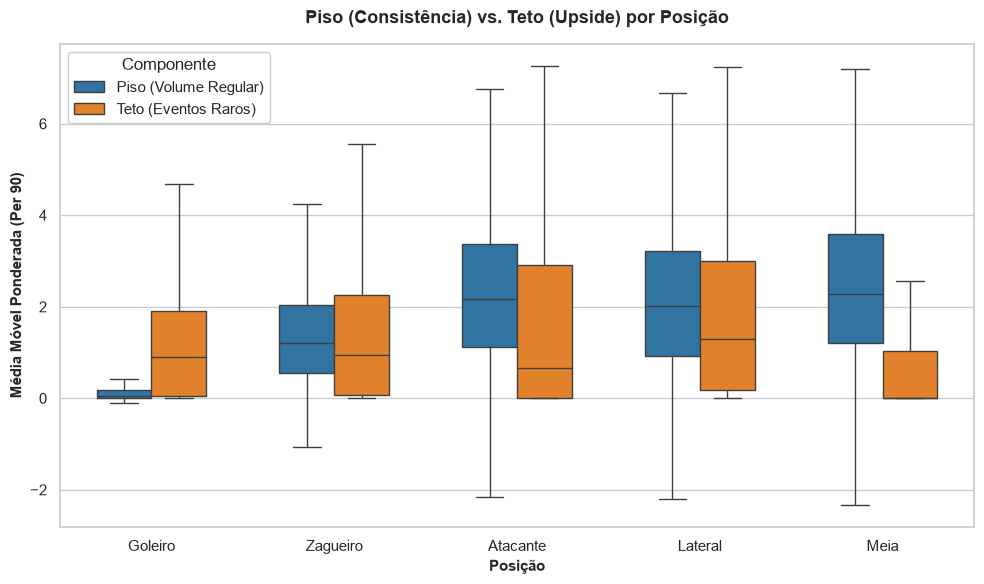

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração visual do gráfico
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid", palette="muted")

# 1. Mapeamento de nomes de posição se ainda não existir
mapa_pos_nome = {1: 'Goleiro', 2: 'Lateral', 3: 'Zagueiro', 4: 'Meia', 5: 'Atacante', 6: 'Técnico'}
df_plot = df[df['entrou_em_campo'] == True].copy()
if 'posicao_nome' not in df_plot.columns:
    df_plot['posicao_nome'] = df_plot['posicao_id'].map(mapa_pos_nome)

# Filtra apenas posições de linha/goleiro (exclui técnicos)
df_plot = df_plot[df_plot['posicao_id'].isin([1, 2, 3, 4, 5])]

# ── Organização dos dados para o Box-plot ─────────────────────────────────
df_melted = df_plot.melt(
    id_vars=['posicao_nome'],
    value_vars=['piso_ewma5', 'teto_ewma5'],
    var_name='Tipo_Metrica',
    value_name='Pontos_Per90'
)
df_melted['Tipo_Metrica'] = df_melted['Tipo_Metrica'].map({
    'piso_ewma5': 'Piso (Volume Regular)',
    'teto_ewma5': 'Teto (Eventos Raros)'
})

# ── Plotagem Única ────────────────────────────────────────────────────────
ax = sns.boxplot(
    data=df_melted,
    x='posicao_nome',
    y='Pontos_Per90',
    hue='Tipo_Metrica',
    palette={'Piso (Volume Regular)': '#1f77b4', 'Teto (Eventos Raros)': '#ff7f0e'},
    showfliers=False,
    width=0.6
)

plt.title('Piso (Consistência) vs. Teto (Upside) por Posição', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Posição', fontsize=11, fontweight='bold')
plt.ylabel('Média Móvel Ponderada (Per 90)', fontsize=11, fontweight='bold')
plt.legend(title='Componente', frameon=True, facecolor='white', framealpha=0.95)

plt.tight_layout()
plt.show()

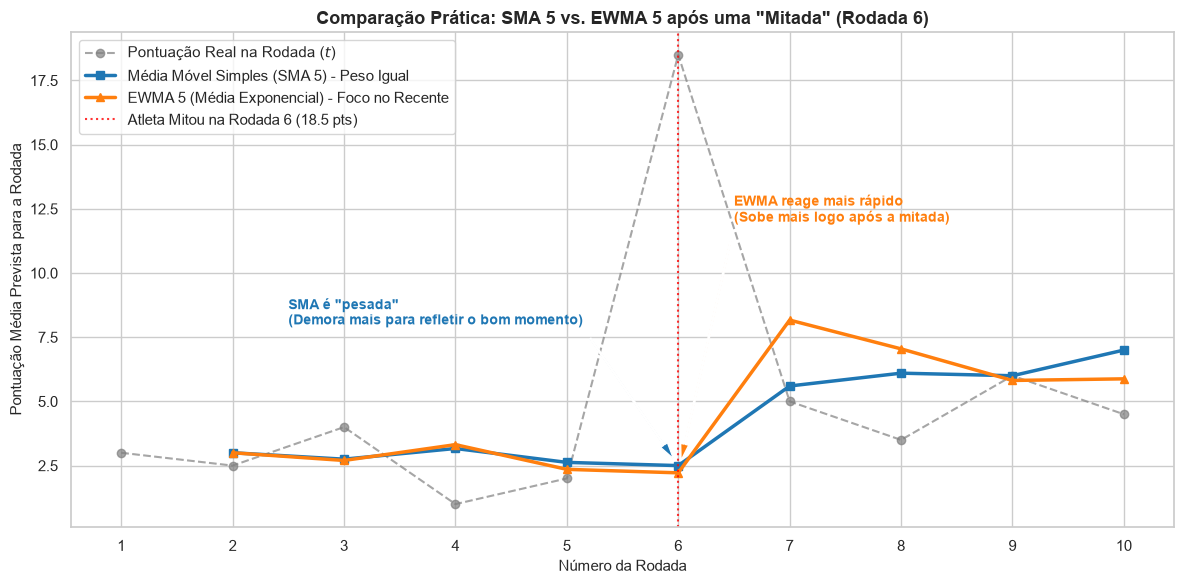

In [13]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# ── Simulação de Pontuações de um Atleta ao longo de 10 Rodadas ──
# Imagine um jogador que vinha mal, mitou na rodada 6 e oscilou depois
dados_exemplo = {
    'rodada': list(range(1, 11)),
    'pontos': [3.0, 2.5, 4.0, 1.0, 2.0, 18.5, 5.0, 3.5, 6.0, 4.5]
}
df_ex = pd.DataFrame(dados_exemplo)

# Cálculo da Média Móvel Simples (SMA 5) - com shift(1) para evitar leakage
df_ex['sma_5'] = df_ex['pontos'].shift(1).rolling(window=5, min_periods=1).mean()

# Cálculo da Média Móvel Exponencial (EWMA 5) - com shift(1)
df_ex['ewma_5'] = df_ex['pontos'].shift(1).ewm(span=5, min_periods=1).mean()

# ── Plotagem Gráfica ──
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

plt.plot(df_ex['rodada'], df_ex['pontos'], marker='o', color='gray', linestyle='--', alpha=0.7, label='Pontuação Real na Rodada ($t$)')
plt.plot(df_ex['rodada'], df_ex['sma_5'], marker='s', color='#1f77b4', linewidth=2.5, label='Média Móvel Simples (SMA 5) - Peso Igual')
plt.plot(df_ex['rodada'], df_ex['ewma_5'], marker='^', color='#ff7f0e', linewidth=2.5, label='EWMA 5 (Média Exponencial) - Foco no Recente')

plt.title('Comparação Prática: SMA 5 vs. EWMA 5 após uma "Mitada" (Rodada 6)', fontsize=13, fontweight='bold')
plt.xlabel('Número da Rodada', fontsize=11)
plt.ylabel('Pontuação Média Prevista para a Rodada', fontsize=11)
plt.xticks(df_ex['rodada'])
plt.axvline(6, color='red', linestyle=':', alpha=0.8, label='Atleta Mitou na Rodada 6 (18.5 pts)')

# Anotações explicativas no gráfico
plt.annotate('EWMA reage mais rápido\n(Sobe mais logo após a mitada)', 
             xy=(6, df_ex.loc[5, 'ewma_5']), xytext=(6.5, 12),
             arrowprops=dict(facecolor='#ff7f0e', shrink=0.05, width=1, headwidth=6),
             fontsize=10, fontweight='bold', color='#ff7f0e')

plt.annotate('SMA é "pesada"\n(Demora mais para refletir o bom momento)', 
             xy=(6, df_ex.loc[5, 'sma_5']), xytext=(2.5, 8),
             arrowprops=dict(facecolor='#1f77b4', shrink=0.05, width=1, headwidth=6),
             fontsize=10, fontweight='bold', color='#1f77b4')

plt.legend(loc='upper left', frameon=True)
plt.tight_layout()
plt.show()

### 2.4 Engenharia de features: Ajustes Focados na posição de Meias

O meio-campo é a posição mais difícil de prever porque mistura estilos totalmente opostos: o volante "operário" (focado em desarmes) e o meia armador (focado em assistências e criação). Para resolver isso, criamos features cirúrgicas:

#### 1. Índice de Armação Pura (`taxa_criacao_armacao`)

Mide o potencial ofensivo e a participação do jogador na criação de jogadas.

$$\text{Armacao} = (\text{A} \cdot 3.0) + (\text{FS} \cdot 1.0) + (\text{FT} \cdot 2.0)$$

* **O que significa:** Pesa as assistências ($\text{A}$), faltas sofridas ($\text{FS}$) e finalizações perigosas/trave ($\text{FT}$).

---

#### 2. Perfil "Box-to-Box" / Intensidade (`perfil_volante_intensidade`)

Mede a pegada defensiva e a roubada de bola do atleta.

$$\text{Intensidade} = (\text{DS} \cdot 1.5) + (\text{FC} \cdot -0.3)$$

* **O que significa:** Recompensa os desarmes certos ($\text{DS}$) e desconta levemente o excesso de faltas cometidas ($\text{FC}$).

---

#### 3. Suavização Móvel de Curto Prazo (`armacao_ewma3` e `intensidade_ewma3`)

Captura o momento recente do atleta usando uma janela mais rápida de **3 jogos**.

$$\text{armacao\_ewma3} = \text{EWMA}_{3}\left(\text{shift}(1)(\text{Armacao})\right)$$

$$\text{intensidade\_ewma3} = \text{EWMA}_{3}\left(\text{shift}(1)(\text{Intensidade})\right)$$

* **O que significa:** O `shift(1)` evita o vazamento de dados (*Data Leakage*) olhando apenas para o passado, e o `span=3` faz o modelo reagir instantaneamente se o jogador mudar de função tática na semana.

---

#### 4. Variável Dummy de Setor (`is_meia_armador`)

Classifica boleanamente se o meia joga com perfil predominantemente ofensivo.

$$\text{is\_meia\_armador} = (\text{posicao\_id} == 4) \land (\text{armacao\_ewma3} > \text{intensidade\_ewma3})$$

* **O que significa:** Retorna `1` se o atleta for oficialmente meia e sua média de armação superar a sua intensidade defensiva, facilitando a separação entre Camisas 10 e Volantes.

In [14]:
# ── Ajustes Focados no Padrão de Meias ───────────────────────────────────

# 1. Índice de Armação Pura (Foco em Assistências e Passes decisivos indiretos)
# Meias armadores vivem de passes para finalização (muitas vezes medidos por faltas sofridas no terço final e assistências)
df['taxa_criacao_armacao'] = (
    df['A'].fillna(0) * 3.0 + 
    df['FS'].fillna(0) * 1.0 + 
    df['FT'].fillna(0) * 2.0
)

# 2. Perfil "Box-to-Box" / Volante de Alta Intensidade
# Meias que pontuam muito no piso defensivo (desarmes + faltas cometidas equilibradas)
df['perfil_volante_intensidade'] = (
    df['DS'].fillna(0) * 1.5 + 
    df['FC'].fillna(0) * -0.3
)

# 3. Suavização EWMA específica para o perfil do meia (janela mais curta = reage mais rápido a mudanças de função tática)
df = df.sort_values(['atleta_id', 'ano', 'rodada_id']).reset_index(drop=True)

df['armacao_ewma3'] = (
    df.groupby(['atleta_id', 'ano'])['taxa_criacao_armacao']
    .transform(lambda s: s.shift(1).ewm(span=3, min_periods=1).mean())
)

df['intensidade_ewma3'] = (
    df.groupby(['atleta_id', 'ano'])['perfil_volante_intensidade']
    .transform(lambda s: s.shift(1).ewm(span=3, min_periods=1).mean())
)

# 4. Dummy de Setor (Ajuda o modelo a entender que o comportamento do meia depende de onde ele pisa)
# Se você tiver uma coluna indicando a função específica ou scout de armação predominante:
df['is_meia_armador'] = (df['posicao_id'] == 4) & (df['armacao_ewma3'] > df['intensidade_ewma3']).astype(int)

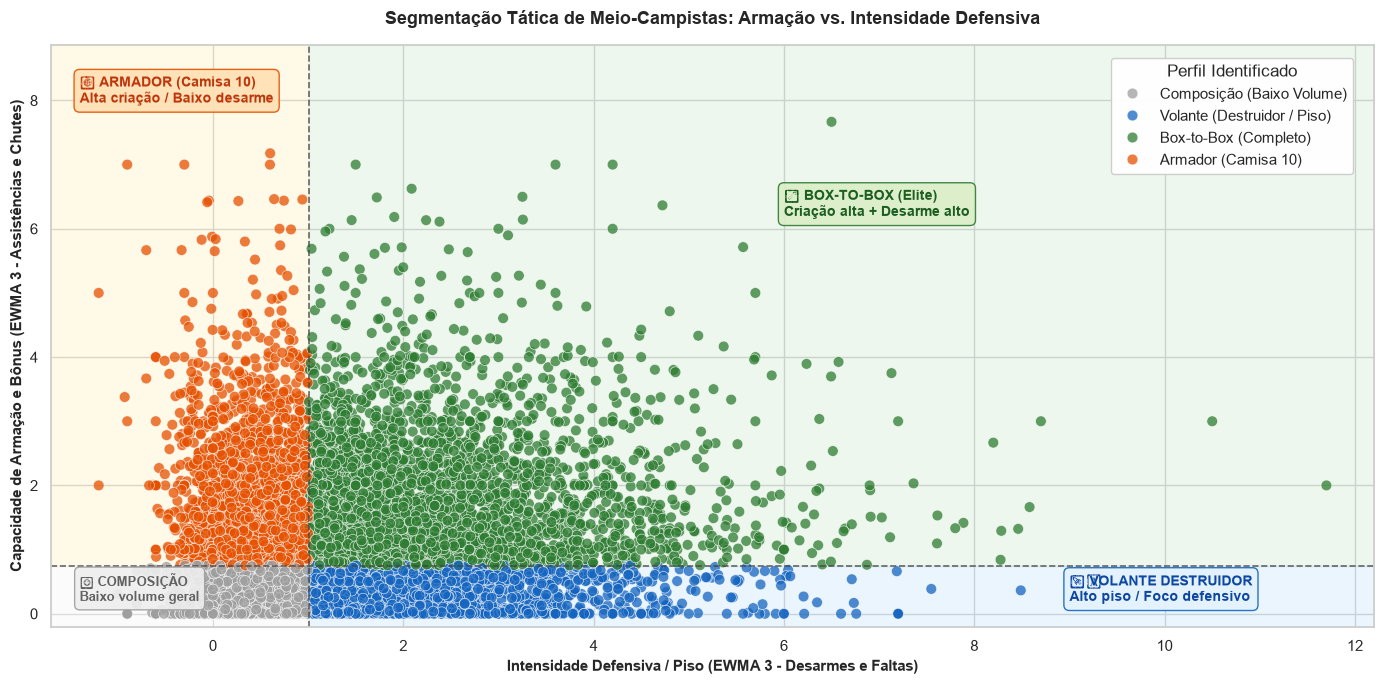

In [15]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# ── 1. Preparação dos Dados de Meio-Campistas ──────────────────────────────
df_meias = df[
    (df['posicao_id'] == 4) & 
    (df['entrou_em_campo'] == True) & 
    (df['minutos_jogados'] >= 45)
].copy()

if 'armacao_ewma3' not in df_meias.columns:
    df_meias['taxa_criacao_armacao'] = (
        df_meias['A'].fillna(0) * 3.0 + 
        df_meias['FS'].fillna(0) * 1.0 + 
        df_meias['FT'].fillna(0) * 2.0
    )
    df_meias['perfil_volante_intensidade'] = (
        df_meias['DS'].fillna(0) * 1.5 + 
        df_meias['FC'].fillna(0) * -0.3
    )
    df_meias = df_meias.sort_values(['atleta_id', 'ano', 'rodada_id']).reset_index(drop=True)
    df_meias['armacao_ewma3'] = df_meias.groupby(['atleta_id', 'ano'])['taxa_criacao_armacao'].transform(lambda s: s.shift(1).ewm(span=3, min_periods=1).mean())
    df_meias['intensidade_ewma3'] = df_meias.groupby(['atleta_id', 'ano'])['perfil_volante_intensidade'].transform(lambda s: s.shift(1).ewm(span=3, min_periods=1).mean())

df_meias = df_meias.dropna(subset=['intensidade_ewma3', 'armacao_ewma3'])

# ── 2. Classificação Categórica dos 4 Arquétipos ───────────────────────────
med_x = df_meias['intensidade_ewma3'].median()
med_y = df_meias['armacao_ewma3'].median()

def classificar_perfil(row):
    if row['intensidade_ewma3'] >= med_x and row['armacao_ewma3'] >= med_y:
        return 'Box-to-Box (Completo)'
    elif row['intensidade_ewma3'] < med_x and row['armacao_ewma3'] >= med_y:
        return 'Armador (Camisa 10)'
    elif row['intensidade_ewma3'] >= med_x and row['armacao_ewma3'] < med_y:
        return 'Volante (Destruidor / Piso)'
    else:
        return 'Composição (Baixo Volume)'

df_meias['perfil_meia'] = df_meias.apply(classificar_perfil, axis=1)

# ── 3. Plotagem Visual com Layout Ajustado ────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 7))
sns.set_theme(style="whitegrid")

x_min, x_max = df_meias['intensidade_ewma3'].min() - 0.5, df_meias['intensidade_ewma3'].max() + 0.5
y_min, y_max = df_meias['armacao_ewma3'].min() - 0.2, df_meias['armacao_ewma3'].max() + 1.2 # Respiro extra em Y

# Zonas de Fundo
ax.fill_between([x_min, med_x], med_y, y_max, color='#ffecb3', alpha=0.30)  # Armador
ax.fill_between([med_x, x_max], med_y, y_max, color='#c8e6c9', alpha=0.30)  # Box-to-box
ax.fill_between([med_x, x_max], y_min, med_y, color='#bbdefb', alpha=0.30)  # Volante
ax.fill_between([x_min, med_x], y_min, med_y, color='#f5f5f5', alpha=0.40)  # Composição

paleta_cores = {
    'Armador (Camisa 10)': '#e65100',
    'Box-to-Box (Completo)': '#2e7d32',
    'Volante (Destruidor / Piso)': '#1565c0',
    'Composição (Baixo Volume)': '#9e9e9e'
}

sns.scatterplot(
    data=df_meias,
    x='intensidade_ewma3',
    y='armacao_ewma3',
    hue='perfil_meia',
    palette=paleta_cores,
    alpha=0.75,
    s=60,
    edgecolor='white',
    linewidth=0.5,
    ax=ax
)

ax.axvline(med_x, color='#424242', linestyle='--', linewidth=1.2, alpha=0.8)
ax.axhline(med_y, color='#424242', linestyle='--', linewidth=1.2, alpha=0.8)

# Rótulos reposicionados para evitar sobreposições
ax.text(x_min + 0.3, y_max - 0.9, '🎯 ARMADOR (Camisa 10)\nAlta criação / Baixo desarme', 
        fontsize=10, fontweight='bold', color='#bf360c', bbox=dict(boxstyle='round,pad=0.4', facecolor='#ffe0b2', edgecolor='#e65100', alpha=0.9))

# Rótulo Box-to-Box puxado para o centro do quadrante verde superior direito
ax.text(6.0, 6.2, '⭐ BOX-TO-BOX (Elite)\nCriação alta + Desarme alto', 
        fontsize=10, fontweight='bold', color='#1b5e20', bbox=dict(boxstyle='round,pad=0.4', facecolor='#dcedc8', edgecolor='#2e7d32', alpha=0.9))

ax.text(x_max - 3.2, y_min + 0.4, '🛡️ VOLANTE DESTRUIDOR\nAlto piso / Foco defensivo', 
        fontsize=10, fontweight='bold', color='#0d47a1', bbox=dict(boxstyle='round,pad=0.4', facecolor='#e3f2fd', edgecolor='#1565c0', alpha=0.9))

ax.text(x_min + 0.3, y_min + 0.4, '⚪ COMPOSIÇÃO\nBaixo volume geral', 
        fontsize=9, fontweight='bold', color='#616161', bbox=dict(boxstyle='round,pad=0.4', facecolor='#eeeeee', edgecolor='#9e9e9e', alpha=0.9))

ax.set_title('Segmentação Tática de Meio-Campistas: Armação vs. Intensidade Defensiva', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Intensidade Defensiva / Piso (EWMA 3 - Desarmes e Faltas)', fontsize=11, fontweight='bold')
ax.set_ylabel('Capacidade de Armação e Bônus (EWMA 3 - Assistências e Chutes)', fontsize=11, fontweight='bold')
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)

# Legenda deslocada para fora da área de pontos superiores
ax.legend(title='Perfil Identificado', loc='upper right', bbox_to_anchor=(0.99, 0.99), frameon=True, facecolor='white', framealpha=0.95)

plt.tight_layout()
plt.show()

findfont: Failed to find font weight semibold, now using 700.


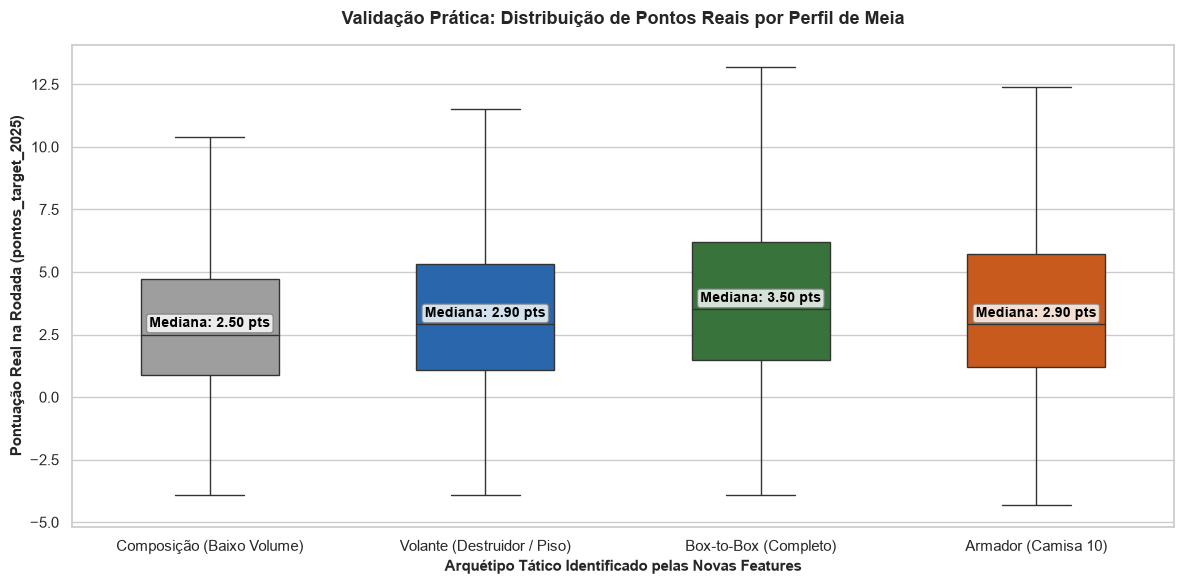

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# ── 1. Garante que os dados de meias e perfis estão prontos ───────────────
df_meias = df[
    (df['posicao_id'] == 4) & 
    (df['entrou_em_campo'] == True) & 
    (df['minutos_jogados'] >= 45)
].copy()

if 'perfil_meia' not in df_meias.columns:
    # Recalcula rapidamente caso não tenha rodado a célula anterior
    df_meias['taxa_criacao_armacao'] = df_meias['A'].fillna(0) * 3.0 + df_meias['FS'].fillna(0) * 1.0 + df_meias['FT'].fillna(0) * 2.0
    df_meias['perfil_volante_intensidade'] = df_meias['DS'].fillna(0) * 1.5 + df_meias['FC'].fillna(0) * -0.3
    df_meias = df_meias.sort_values(['atleta_id', 'ano', 'rodada_id']).reset_index(drop=True)
    df_meias['armacao_ewma3'] = df_meias.groupby(['atleta_id', 'ano'])['taxa_criacao_armacao'].transform(lambda s: s.shift(1).ewm(span=3, min_periods=1).mean())
    df_meias['intensidade_ewma3'] = df_meias.groupby(['atleta_id', 'ano'])['perfil_volante_intensidade'].transform(lambda s: s.shift(1).ewm(span=3, min_periods=1).mean())
    
    med_x = df_meias['intensidade_ewma3'].median()
    med_y = df_meias['armacao_ewma3'].median()
    
    def classificar_perfil(row):
        if row['intensidade_ewma3'] >= med_x and row['armacao_ewma3'] >= med_y:
            return 'Box-to-Box (Completo)'
        elif row['intensidade_ewma3'] < med_x and row['armacao_ewma3'] >= med_y:
            return 'Armador (Camisa 10)'
        elif row['intensidade_ewma3'] >= med_x and row['armacao_ewma3'] < med_y:
            return 'Volante (Destruidor / Piso)'
        else:
            return 'Composição (Baixo Volume)'
            
    df_meias['perfil_meia'] = df_meias.apply(classificar_perfil, axis=1)

# ── 2. Plotagem do Box-plot Comparativo ───────────────────────────────────
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

paleta_perfis = {
    'Box-to-Box (Completo)': '#2e7d32',
    'Armador (Camisa 10)': '#e65100',
    'Volante (Destruidor / Piso)': '#1565c0',
    'Composição (Baixo Volume)': '#9e9e9e'
}

ax = sns.boxplot(
    data=df_meias,
    x='perfil_meia',
    y='pontos_target_2025',
    palette=paleta_perfis,
    showfliers=False,  # Remove outliers extremos para focar na caixa principal (IQR)
    width=0.5
)

plt.title('Validação Prática: Distribuição de Pontos Reais por Perfil de Meia', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Arquétipo Tático Identificado pelas Novas Features', fontsize=11, fontweight='bold')
plt.ylabel('Pontuação Real na Rodada (pontos_target_2025)', fontsize=11, fontweight='bold')

# Adiciona a mediana exata como texto em cima de cada box
medias_por_grupo = df_meias.groupby('perfil_meia')['pontos_target_2025'].median()
for i, perfil in enumerate(ax.get_xticklabels()):
    nome_perfil = perfil.get_text()
    if nome_perfil in medias_por_grupo:
        val_med = medias_por_grupo[nome_perfil]
        ax.text(i, val_med + 0.3, f'Mediana: {val_med:.2f} pts', 
                horizontalalignment='center', size=10, color='black', weight='semibold',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8, edgecolor='gray'))

plt.tight_layout()
plt.show()

### 3 Tratamento de Cold Start e ajuste nas features gerais

Ausência de histórico recente na mesma temporada (trocas de clube, pré-temporada). O modelo depende fortemente do preço inicial de mercado, posição e mando.

Criação da flag binária `is_rodada_1` e imputação neutra (`0.0`) nos *lags* da primeira rodada.

In [17]:
# ── 1. Ordenação Temporal Obrigatória ────────────────────────────────────
df = df.sort_values(by=['atleta_id', 'ano', 'rodada_id']).reset_index(drop=True)

# 2. Flag de Rodada 1
df['is_rodada_1'] = (df['rodada_id'] == 1).astype(int)


# ── 3. Construção do Fallback Inteligente (Clube + Posição no Ano Anterior) ─
# Calcula a média de pontos por ano, clube e posição
hist_clube_pos = (
    df.groupby(['ano', 'clube_id', 'posicao_id'])['pontos_target_2025']
    .mean()
    .reset_index()
)
hist_clube_pos['ano_alvo'] = hist_clube_pos['ano'] + 1
dict_cold_start = hist_clube_pos.set_index(['ano_alvo', 'clube_id', 'posicao_id'])['pontos_target_2025'].to_dict()

# Fallback secundário: média da posição no ano anterior (caso o clube seja novo na série A)
hist_posicao = df.groupby(['ano', 'posicao_id'])['pontos_target_2025'].mean().reset_index()
hist_posicao['ano_alvo'] = hist_posicao['ano'] + 1
dict_cold_start_pos = hist_posicao.set_index(['ano_alvo', 'posicao_id'])['pontos_target_2025'].to_dict()

# Fallback final absoluto: média geral da posição na história da base
media_geral_pos = df.groupby('posicao_id')['pontos_target_2025'].mean().to_dict()

def get_cold_start_baseline(row):
    ano = row['ano']
    clube = row['clube_id']
    pos = row['posicao_id']
    
    # 1. Tenta clube + posição do ano anterior
    if (ano, clube, pos) in dict_cold_start:
        return dict_cold_start[(ano, clube, pos)]
    # 2. Tenta apenas posição do ano anterior
    elif (ano, pos) in dict_cold_start_pos:
        return dict_cold_start_pos[(ano, pos)]
    # 3. Último recurso: média geral daquela posição
    else:
        return media_geral_pos.get(pos, 3.0)

# Atribui o baseline inteligente para cada linha
df['baseline_cold_start'] = df.apply(get_cold_start_baseline, axis=1)


# ── 4. Criação de Lags e Janelas Móveis com Fallback Contextual ───────────
col_target = 'pontos_target_2025'
grouped = df.groupby(['atleta_id', 'ano'])[col_target]

# Lags pontuais: Se for Rodada 1 (ou sem histórico), herda o baseline do sistema do clube/posição
df['feat_pontos_lag1'] = grouped.shift(1).fillna(df['baseline_cold_start'])
df['feat_pontos_lag2'] = grouped.shift(2).fillna(df['baseline_cold_start'])

# Janelas móveis com min_periods=1 (usando o baseline inteligente para preencher vazios)
df['feat_media_pontos_3j'] = (
    grouped
    .transform(lambda x: x.shift(1).rolling(window=3, min_periods=1).mean())
    .fillna(df['baseline_cold_start'])
)

df['feat_media_pontos_5j'] = (
    grouped
    .transform(lambda x: x.shift(1).rolling(window=5, min_periods=1).mean())
    .fillna(df['baseline_cold_start'])
)

# Desvio padrão: Como volatilidade não pode ser estimada com 1 único dado, mantemos 0.0 na R1
df['feat_std_pontos_5j'] = (
    grouped
    .transform(lambda x: x.shift(1).rolling(window=5, min_periods=2).std())
    .fillna(0.0)
)

# Opcional: Remove a coluna auxiliar de baseline se não quiser poluir o dataset final
df = df.drop(columns=['baseline_cold_start'])


# ── 5. Inspeção Estrutural Enxuta ────────────────────────────────────────
features_novas = [
    'feat_pontos_lag1',
    'feat_pontos_lag2',
    'feat_media_pontos_3j',
    'feat_media_pontos_5j',
    'feat_std_pontos_5j'
]

print(f"Shape atual do DataFrame: {df.shape}")
print(f"\nNovas colunas criadas ({len(features_novas)}):")
print(features_novas)
print(f"\nExemplo de valores na Rodada 1 (com baseline de clube/posição):")
print(df[df['is_rodada_1'] == 1][['atleta_id', 'ano', 'clube_id', 'posicao_id', 'feat_media_pontos_3j']].head(3))

Shape atual do DataFrame: (115613, 80)

Novas colunas criadas (5):
['feat_pontos_lag1', 'feat_pontos_lag2', 'feat_media_pontos_3j', 'feat_media_pontos_5j', 'feat_std_pontos_5j']

Exemplo de valores na Rodada 1 (com baseline de clube/posição):
     atleta_id   ano  clube_id  posicao_id  feat_media_pontos_3j
65       10004  2023       114           6                  4.11
119      10004  2025       105           6                  3.20
152      10005  2022       127           6                  3.51


Passo 1: Ajuste Temporal de Mercado e Variáveis de Jogo Atual
Variáveis como media_num (média acumulada) fornecidas pela API pós-rodada contêm o resultado do jogo atual. Precisamos defasar (shift(1)) essas métricas para garantir que o modelo só veja o que o atleta acumulou até entrar na rodada.

In [18]:
# Garante a ordenação causal
df = df.sort_values(by=['atleta_id', 'ano', 'rodada_id']).reset_index(drop=True)

# Defasagem de métricas acumuladas/mercado para evitar leakage
cols_mercado_acumuladas = ['media_num', 'preco_num', 'variacao_num', 'jogos_num', 'pontos_num']
for col in cols_mercado_acumuladas:
    if col in df.columns:
        df[f'{col}_lag1'] = df.groupby(['atleta_id', 'ano'])[col].shift(1).fillna(0.0)

Passo 2: Engenharia de Features para Minutos, Presença e Regime
minutos_jogados & entrou_em_campo: Transformamos em histórico recente via EWMA (para saber se o atleta é titular absoluto, entra no fim dos jogos ou vem de lesão).

regime_temporada: Como é uma variável categórica (ex: calendário regular, turnos, etc.), aplicamos One-Hot Encoding para que o modelo entenda os diferentes contextos de calendário.

In [19]:
# ── 1. Média móvel exponencial de minutos jogados nas últimas 5 rodadas ────
df['minutos_ewma5'] = (
    df.groupby(['atleta_id', 'ano'])['minutos_jogados']
    .transform(lambda s: s.shift(1).ewm(span=5, min_periods=1).mean())
    .fillna(0.0)
)

# ── 2. Taxa de presença recente ───────────────────────────────────────────
df['entrou_em_campo_int'] = df['entrou_em_campo'].astype(int)

df['taxa_presenca_ewma5'] = (
    df.groupby(['atleta_id', 'ano'])['entrou_em_campo_int']
    .transform(lambda s: s.shift(1).ewm(span=5, min_periods=1).mean())
    .fillna(0.0)
)
df = df.drop(columns=['entrou_em_campo_int'])

# ── 3. Tratamento e Renomeação Limpa do Regime de Temporada ───────────────
if 'regime_temporada' in df.columns:
    df = pd.get_dummies(df, columns=['regime_temporada'], prefix='regime', drop_first=True, dtype=int)
    
    # Dicionário para padronizar os nomes longos gerados pelo get_dummies
    mapa_renomeacao_regime = {
        'regime_2. Corpo 1º Turno (R4-R20)': 'regime_1turno',
        'regime_3. Corpo 2º Turno (R21-R35)': 'regime_2turno',
        'regime_4. Reta Final (R36-R38)': 'regime_reta_final'
    }
    
    # Renomeia apenas as colunas que existirem no DataFrame
    df = df.rename(columns={k: v for k, v in mapa_renomeacao_regime.items() if k in df.columns})

In [20]:
print(df.shape)
df.columns.to_list

(115613, 89)


<bound method IndexOpsMixin.tolist of Index(['atleta_id', 'apelido', 'ano', 'rodada_id', 'clube_id', 'posicao_id',
       'status_pre', 'status_inicial', 'preco_num', 'variacao_num',
       'media_num', 'jogos_num', 'pontos_num', 'minutos_jogados',
       'entrou_em_campo', 'home_dummy', 'opponent', 'match_id', 'G', 'A', 'SG',
       'FF', 'FT', 'FD', 'DP', 'DE', 'DS', 'FS', 'PS', 'GS', 'GC', 'CA', 'CV',
       'FC', 'I', 'PP', 'PC', 'rodada_cbf_original', 'posicao_nome',
       'pontos_target_2025', 'clube_media_pts_feitos_l5',
       'adv_media_pts_cedidos_l5', 'feat_pontos_lag1', 'feat_pontos_lag2',
       'feat_media_pontos_3j', 'feat_media_pontos_5j', 'feat_std_pontos_5j',
       'pts_piso', 'pts_teto', 'pts_piso_gol', 'pts_teto_gol', 'vol_defensivo',
       'vol_chutes', 'vol_ofensivo_piso', 'piso_per90', 'teto_per90',
       'vol_def_per90', 'vol_of_per90', 'chutes_per90', 'piso_ewma5',
       'teto_ewma5', 'vol_def_ewma5', 'vol_of_ewma5', 'chutes_ewma5',
       'pts_piso_gol_ew

In [21]:
cols_ids = ['atleta_id', 'apelido', 'ano', 'rodada_id', 'clube_id', 'opponent', 'match_id', 'posicao_nome']
col_target = ['pontos_target_2025']

cols_to_predict = [
    # Mercado e Posição (Defasados para evitar Data Leakage)
    'preco_num_lag1', 'variacao_num_lag1', 'media_num_lag1', 'jogos_num_lag1', 'pontos_num_lag1', 
    'status_pre', 'status_inicial', 'home_dummy', 'posicao_id', 'is_rodada_1',
    
    # Contexto de Equipe e Oponente (L5)
    'clube_media_pts_feitos_l5', 'adv_media_pts_cedidos_l5',
    
    # Histórico Individual de Pontos (Lags e Médias Móveis)
    'feat_pontos_lag1', 'feat_pontos_lag2', 
    'feat_media_pontos_3j', 'feat_media_pontos_5j', 'feat_std_pontos_5j',
    
    # Decomposição de Piso, Teto e Volatilidade Histórica (EWMA 5)
    'piso_ewma5', 'teto_ewma5', 'vol_def_ewma5', 'vol_of_ewma5', 
    'chutes_ewma5', 'pts_piso_gol_ewma5', 'disciplina_ewma5',
    
    # Confiabilidade, Frequência e Disciplina Tática
    'minutos_ewma5', 'taxa_presenca_ewma5',
    'ratio_teto_piso', 'taxa_conversao_l5', 'piso_zscore_posicao',
    
    # Especializações Setoriais (Meias e Volantes)
    'taxa_criacao_armacao', 'perfil_volante_intensidade', 
    'armacao_ewma3', 'intensidade_ewma3', 'is_meia_armador',
    
    # Regimes de Temporada (Limpos)
    'regime_1turno', 'regime_2turno', 'regime_reta_final'
]

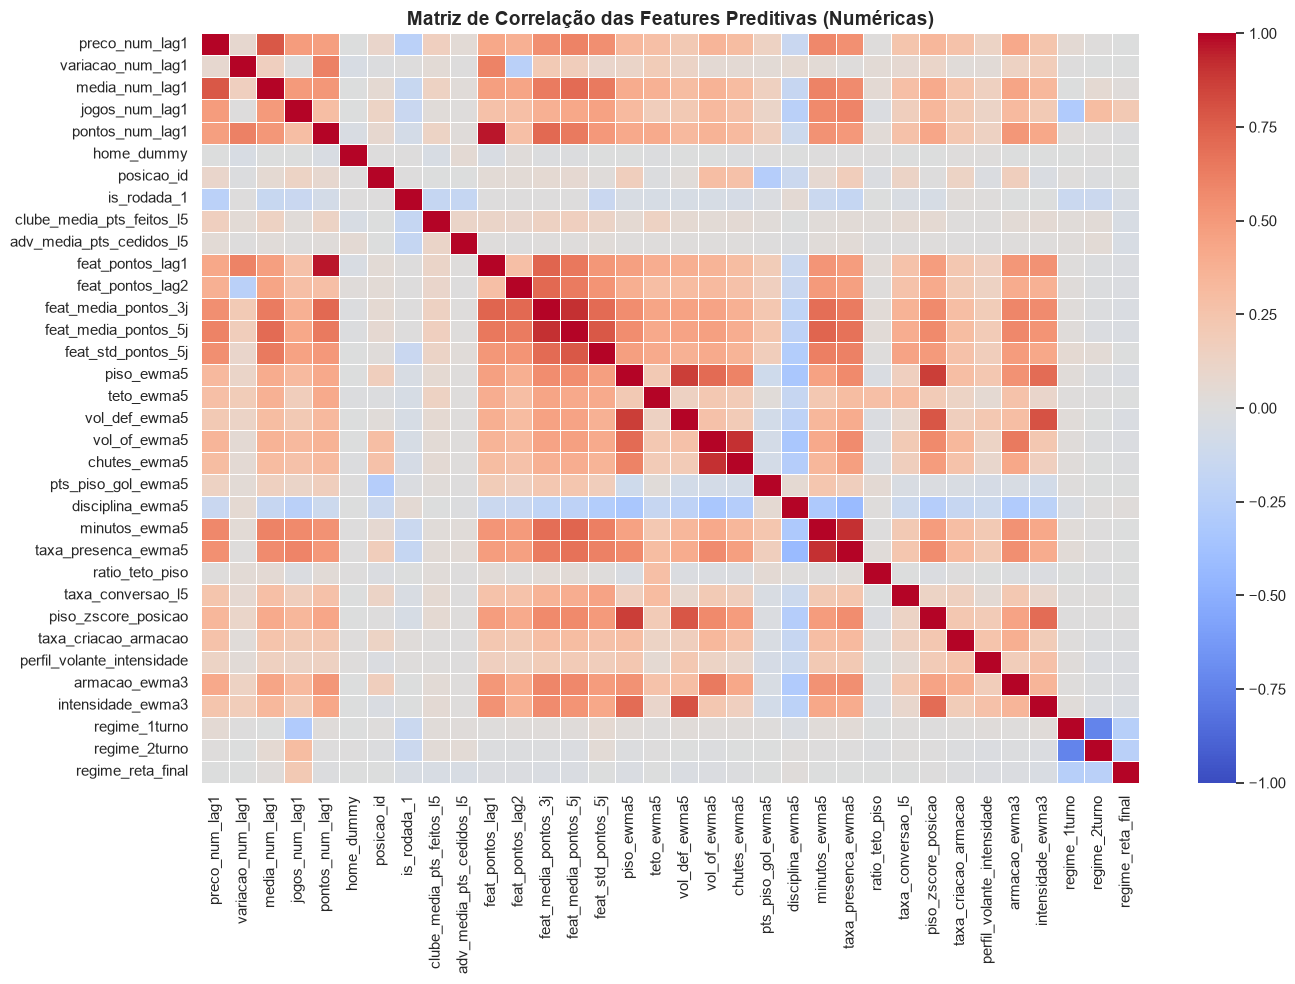


Pares de features altamente correlacionadas (> 0.85) para avaliar poda:
- minutos_ewma5 ↔ taxa_presenca_ewma5
- piso_ewma5 ↔ vol_def_ewma5
- feat_media_pontos_3j ↔ feat_media_pontos_5j
- chutes_ewma5 ↔ vol_of_ewma5
- piso_ewma5 ↔ piso_zscore_posicao
- feat_pontos_lag1 ↔ pontos_num_lag1


In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ── Opção 1: Filtra apenas colunas numéricas da sua lista de features
features_num_modelo = df[cols_to_predict].select_dtypes(include=[np.number]).columns.tolist()

# Calcula a matriz de correlação apenas com números
plt.figure(figsize=(14, 10))
corr_matrix = df[features_num_modelo].corr()

# Plota o heatmap limpo
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Matriz de Correlação das Features Preditivas (Numéricas)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Identifica pares com correlação muito alta (> 0.85) para avaliar poda
alta_corr = (corr_matrix.abs() > 0.85) & (corr_matrix != 1.0)
colunas_redundantes = set()
for col in alta_corr.columns:
    s = alta_corr[col]
    if s.any():
        for idx in s[s].index:
            colunas_redundantes.add(tuple(sorted([col, idx])))

print("\nPares de features altamente correlacionadas (> 0.85) para avaliar poda:")
for par in list(colunas_redundantes)[:10]:
    print(f"- {par[0]} ↔ {par[1]}")

### Análise dos pares correlacionados (|r| > 0,85)

A matriz de correlação identificou cinco pares com associação muito forte. Para cada um, segue a interpretação e a recomendação de tratamento no pipeline.

---

**1. `feat_pontos_lag1` ↔ `pontos_num_lag1`**

Ambas capturam a pontuação da rodada anterior: `pontos_num_lag1` vem da API e `feat_pontos_lag1` é o lag calculado no pipeline sobre o target homogeneizado.

**Recomendação:** remover `pontos_num_lag1` e manter apenas `feat_pontos_lag1`, para evitar redundância e preservar o padrão de nomenclatura do pipeline.

---

**2. `minutos_ewma5` ↔ `taxa_presenca_ewma5`**

As duas medem regularidade de participação: minutos jogados recentemente e frequência de presença em campo. Atletas que entram com frequência tendem a acumular mais minutos, o que explica a correlação elevada.

**Recomendação:** manter ambas se o objetivo for distinguir titulares absolutos (90 min) de reservas que entram pontualmente. Para um conjunto mais enxuto, manter só `minutos_ewma5`, que já reflete a intensidade do tempo em campo.

---

**3. `feat_media_pontos_3j` ↔ `feat_media_pontos_5j`**

Médias móveis de 3 e 5 jogos sobre a pontuação recente.

**Recomendação:** manter ambas. Em modelagem esportiva, essa duplicidade é intencional: a janela de 3 jogos captura momentum imediato (fase atual), enquanto a de 5 jogos reflete estabilidade de médio prazo. Modelos baseados em árvore costumam explorar bem essa diferença.

---

**4. `piso_ewma5` ↔ `piso_zscore_posicao`**

O primeiro é o piso bruto (EWMA de scouts de volume); o segundo é o mesmo sinal padronizado pela posição na rodada.

**Recomendação:** manter ambas. O valor bruto informa a pontuação mínima esperada em pontos; o Z-score indica se esse piso é excepcional ou mediano em relação aos demais da mesma posição.

---

**5. `piso_ewma5` ↔ `vol_def_ewma5` e `chutes_ewma5` ↔ `vol_of_ewma5`**

`vol_def_ewma5` e `vol_of_ewma5` são subconjuntos dos scouts que compõem `piso_ewma5` e o volume ofensivo agregado, respectivamente.

**Recomendação:** para um modelo mais enxuto, remover `vol_def_ewma5` e `vol_of_ewma5` e confiar em `piso_ewma5` e `chutes_ewma5`, que já concentram boa parte da informação de volume defensivo e ofensivo.

In [23]:
cols_ids = ['atleta_id', 'apelido', 'ano', 'rodada_id', 'clube_id', 'opponent', 'match_id', 'posicao_nome']
col_target = ['pontos_target_2025']

cols_to_predict = [
    # Mercado e Posição (Removido o redundante pontos_num_lag1)
    'preco_num_lag1', 'variacao_num_lag1', 'media_num_lag1', 'jogos_num_lag1', 
    'status_pre', 'status_inicial', 'home_dummy', 'posicao_id', 'is_rodada_1',
    
    # Contexto de Equipe e Oponente (L5)
    'clube_media_pts_feitos_l5', 'adv_media_pts_cedidos_l5',
    
    # Histórico Individual de Pontos (Lags e Médias Móveis complementares)
    'feat_pontos_lag1', 'feat_pontos_lag2', 
    'feat_media_pontos_3j', 'feat_media_pontos_5j', 'feat_std_pontos_5j',
    
    # Decomposição de Piso, Teto, Chutes e Disciplina (EWMA 5)
    'piso_ewma5', 'teto_ewma5', 'chutes_ewma5', 'pts_piso_gol_ewma5', 'disciplina_ewma5',
    
    # Confiabilidade e Contexto Relativo
    'minutos_ewma5',  # Mantido (removemos a taxa_presenca para evitar redundância com minutos)
    'ratio_teto_piso', 'taxa_conversao_l5', 'piso_zscore_posicao',
    
    # Especializações Setoriais (Meias e Volantes)
    'taxa_criacao_armacao', 'perfil_volante_intensidade', 
    'armacao_ewma3', 'intensidade_ewma3', 'is_meia_armador',
    
    # Regimes de Temporada (Limpos)
    'regime_1turno', 'regime_2turno', 'regime_reta_final'
]

## Função feature engineering

In [24]:
import sys
from pathlib import Path
import pandas as pd

# Adiciona a raiz do projeto ao path para importar pacotes de src
sys.path.append(str(Path.cwd().parent))

from src.features.engineering import (
    pipeline_gerar_features,
    COLS_IDS,
    COL_TARGET,
    COLS_TO_PREDICT
)

# 1. Executa a pipeline gerando o dataset de modelagem
df_features = pipeline_gerar_features(
    input_path="../data/processed/base_limpa_gm.parquet",
    output_path="../data/processed/dataset_features_modelagem.parquet"
)

# 2. Prepara X e y apenas com atletas que jogaram
df_treino = df_features[df_features['entrou_em_campo']].reset_index(drop=True)

X = df_treino[COLS_TO_PREDICT]
y = df_treino[COL_TARGET]

print(f"Matriz de Features X: {X.shape}")
print(f"Vetor Target y: {y.shape}")

🔄 Carregando base limpa: ../data/processed/base_limpa_gm.parquet...
⚙️  Calculando target homogeneizado (2025)...
⚙️  Calculando features de equipe e adversário (L5)...
⚙️  Calculando features individuais com Cold Start...
⚙️  Calculando scouts derivados e médias exponenciais (EWMA)...
⚙️  Defasando métricas de mercado e codificando regimes...
✅ Pipeline finalizada com sucesso! Shape final: (115613, 69)
💾 Dataset salvo em: ../data/processed/dataset_features_modelagem.parquet
Matriz de Features X: (48481, 34)
Vetor Target y: (48481,)
